# Executive Summary

This notebook investigates the 9–10 October 2014 extreme rainfall event in Genoa, Liguria, using station-based observations from ARPA and gridded precipitation estimates from Open-Meteo.

### Key Findings

- The GENOVA - GEIRATO station recorded **559.0 mm** of precipitation during the event.
- Open-Meteo estimated **68.0 mm**, representing approximately **12.2%** of the station-observed total.
- The total difference between the two datasets was **491.0 mm**.
- The maximum hourly precipitation recorded by ARPA was **135.0 mm**.
- The maximum 3-hour accumulation reached **215.0 mm**.
- The maximum 24-hour accumulation reached **438.4 mm**, corresponding to **78.4% of the total event rainfall**.
- The largest hourly discrepancy between ARPA and Open-Meteo reached **133.7 mm**.

### Main Hazard Insight

The analysis indicates that the event was characterized by highly intense and temporally concentrated rainfall. The substantial difference between local station observations and gridded precipitation estimates also highlights the importance of ground-based observations when assessing highly localized extreme rainfall and potential flash flood hazard.

### Scope and Limitation

The rainfall analysis is based on a single monitoring station and therefore does not represent the spatial distribution of rainfall across Liguria. The spatial component provides a **station-based hazard context**, while the dataset comparison evaluates differences between local observations and gridded precipitation estimates.

# Spatial Analysis of Flash Flood Risk – Liguria, Italy

## Project: Italy Natural Hazard Intelligence

This notebook performs spatial analysis of rainfall and flash flood hazard indicators in Liguria, Italy.

## Objectives

- Characterize the temporal intensity and concentration of the 9–10 October 2014 rainfall event
- Compare local station observations with gridded precipitation estimates
- Quantify differences between the two precipitation datasets
- Provide a GIS-based spatial context around the GENOVA - GEIRATO station
- Translate rainfall characteristics into flash flood hazard and decision-support insights

## Study Area and Data Sources

This analysis focuses on Liguria, Italy, with particular attention to the Genoa area and the GENOVA - GEIRATO rainfall station.

The spatial analysis combines:

- ARPA Liguria observed rainfall data
- Open-Meteo hourly precipitation data
- Official Liguria regional boundaries
- Official municipal boundaries (Comuni)

The spatial reference system of the original administrative boundary dataset is EPSG:7791. The spatial layers are reprojected to WGS84 (EPSG:4326) for visualization and geographic analysis.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [32]:
# Load processed rainfall data

precipitation = pd.read_csv("../data/processed/precipitation_comparison.csv")

print("Shape:", precipitation.shape)
print("\nColumns:")
print(precipitation.columns.tolist())

precipitation.head()

Shape: (107, 5)

Columns:
['time', 'arpal_precipitation_mm', 'openmeteo_precipitation_mm', 'difference_mm', 'absolute_error_mm']


,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm
0,2014-10-08 00:00:00,0.0,1.0,-1.0,1.0
1,2014-10-08 01:00:00,0.0,1.3,-1.3,1.3
2,2014-10-08 02:00:00,0.0,1.5,-1.5,1.5
3,2014-10-08 03:00:00,0.6,1.5,-0.9,0.9
4,2014-10-08 04:00:00,0.0,1.5,-1.5,1.5


In [33]:
# Convert time column to datetime

precipitation["time"] = pd.to_datetime(precipitation["time"])

print("Time range:")
print(precipitation["time"].min(), "→", precipitation["time"].max())

print("\nTime column type:")
print(precipitation["time"].dtype)

Time range:
2014-10-08 00:00:00 → 2014-10-12 23:00:00

Time column type:
datetime64[us]


In [34]:
from pathlib import Path

processed_path = Path("../data/processed")

print("Processed files:")
for file in processed_path.glob("*.csv"):
    print("-", file.name)

Processed files:
- extreme_rainfall_events.csv
- precipitation_comparison.csv
- severity_summary.csv


In [35]:
import pandas as pd

# Load processed data
extreme_rainfall = pd.read_csv("../data/processed/extreme_rainfall_events.csv")
precipitation = pd.read_csv("../data/processed/precipitation_comparison.csv")
severity_summary = pd.read_csv("../data/processed/severity_summary.csv")

print("Processed data loaded successfully!")
print()

print("1. Extreme rainfall:")
print("Shape:", extreme_rainfall.shape)
print("Columns:", extreme_rainfall.columns.tolist())

print()
print("2. Precipitation comparison:")
print("Shape:", precipitation.shape)
print("Columns:", precipitation.columns.tolist())

print()
print("3. Severity summary:")
print("Shape:", severity_summary.shape)
print("Columns:", severity_summary.columns.tolist())

Processed data loaded successfully!

1. Extreme rainfall:
Shape: (12, 6)
Columns: ['time', 'arpal_precipitation_mm', 'openmeteo_precipitation_mm', 'difference_mm', 'absolute_error_mm', 'severity']

2. Precipitation comparison:
Shape: (107, 5)
Columns: ['time', 'arpal_precipitation_mm', 'openmeteo_precipitation_mm', 'difference_mm', 'absolute_error_mm']

3. Severity summary:
Shape: (3, 6)
Columns: ['severity', 'hours', 'max_rainfall', 'mean_rainfall', 'mean_openmeteo', 'mean_difference']


In [36]:
# Preview extreme rainfall events

print("Extreme rainfall events:")
display(extreme_rainfall)

Extreme rainfall events:


,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm,severity
0,2014-10-08 20:00:00,41.4,0.6,40.8,40.8,Heavy
1,2014-10-09 06:00:00,42.0,1.2,40.8,40.8,Heavy
2,2014-10-09 07:00:00,23.8,1.8,22.0,22.0,Heavy
3,2014-10-09 08:00:00,53.0,2.6,50.4,50.4,Very Heavy
4,2014-10-09 18:00:00,21.4,1.5,19.9,19.9,Heavy
5,2014-10-09 19:00:00,30.0,1.0,29.0,29.0,Heavy
6,2014-10-09 20:00:00,135.0,1.3,133.7,133.7,Exceptional
7,2014-10-09 21:00:00,50.0,1.8,48.2,48.2,Very Heavy
8,2014-10-10 08:00:00,56.8,0.6,56.2,56.2,Very Heavy
9,2014-10-10 10:00:00,43.2,0.5,42.7,42.7,Heavy


In [37]:
# Basic statistics of extreme rainfall

print("Extreme rainfall statistics:")
display(extreme_rainfall.describe())

Extreme rainfall statistics:


,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm
count,12.000000,12.000000,12.000000,12.000000
mean,45.900000,1.158333,44.741667,44.741667
std,30.571704,0.673469,30.495021,30.495021
min,21.400000,0.500000,19.900000,19.900000
25%,28.450000,0.575000,27.250000,27.250000
50%,41.700000,1.100000,40.800000,40.800000
75%,50.750000,1.575000,48.750000,48.750000
max,135.000000,2.600000,133.700000,133.700000


In [38]:
# Sort extreme rainfall events by ARPA rainfall

extreme_sorted = extreme_rainfall.sort_values(
    by="arpal_precipitation_mm",
    ascending=False
)

display(extreme_sorted)

,time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm,severity
6,2014-10-09 20:00:00,135.0,1.3,133.7,133.7,Exceptional
8,2014-10-10 08:00:00,56.8,0.6,56.2,56.2,Very Heavy
3,2014-10-09 08:00:00,53.0,2.6,50.4,50.4,Very Heavy
7,2014-10-09 21:00:00,50.0,1.8,48.2,48.2,Very Heavy
9,2014-10-10 10:00:00,43.2,0.5,42.7,42.7,Heavy
1,2014-10-09 06:00:00,42.0,1.2,40.8,40.8,Heavy
0,2014-10-08 20:00:00,41.4,0.6,40.8,40.8,Heavy
11,2014-10-11 01:00:00,32.8,0.5,32.3,32.3,Heavy
5,2014-10-09 19:00:00,30.0,1.0,29.0,29.0,Heavy
2,2014-10-09 07:00:00,23.8,1.8,22.0,22.0,Heavy


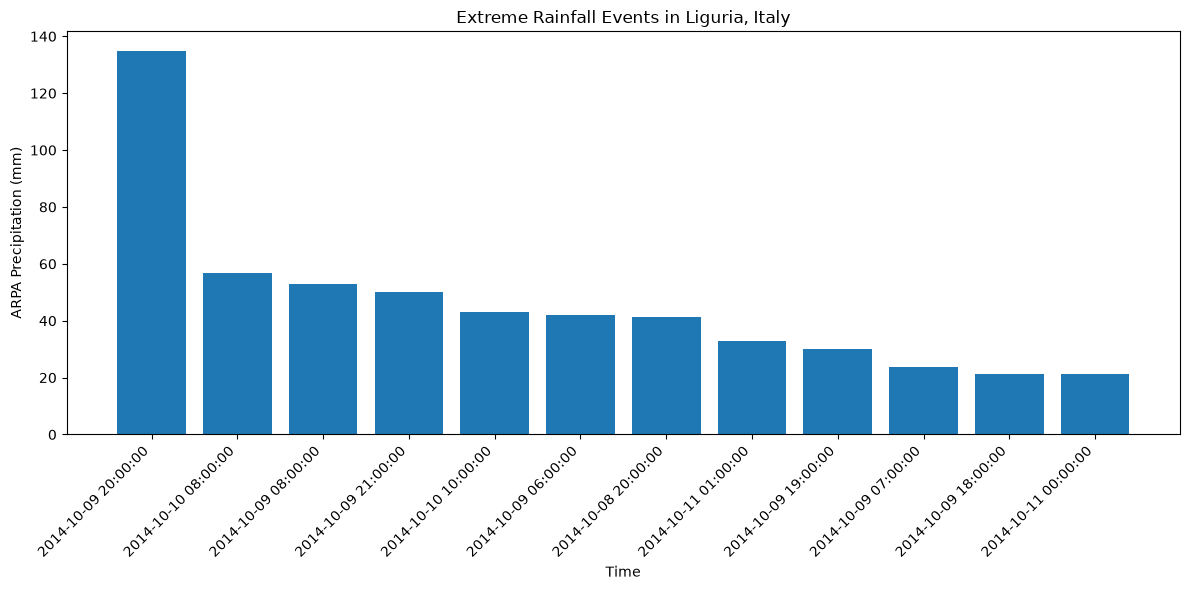

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    extreme_sorted["time"].astype(str),
    extreme_sorted["arpal_precipitation_mm"]
)

plt.xlabel("Time")
plt.ylabel("ARPA Precipitation (mm)")
plt.title("Extreme Rainfall Events in Liguria, Italy")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

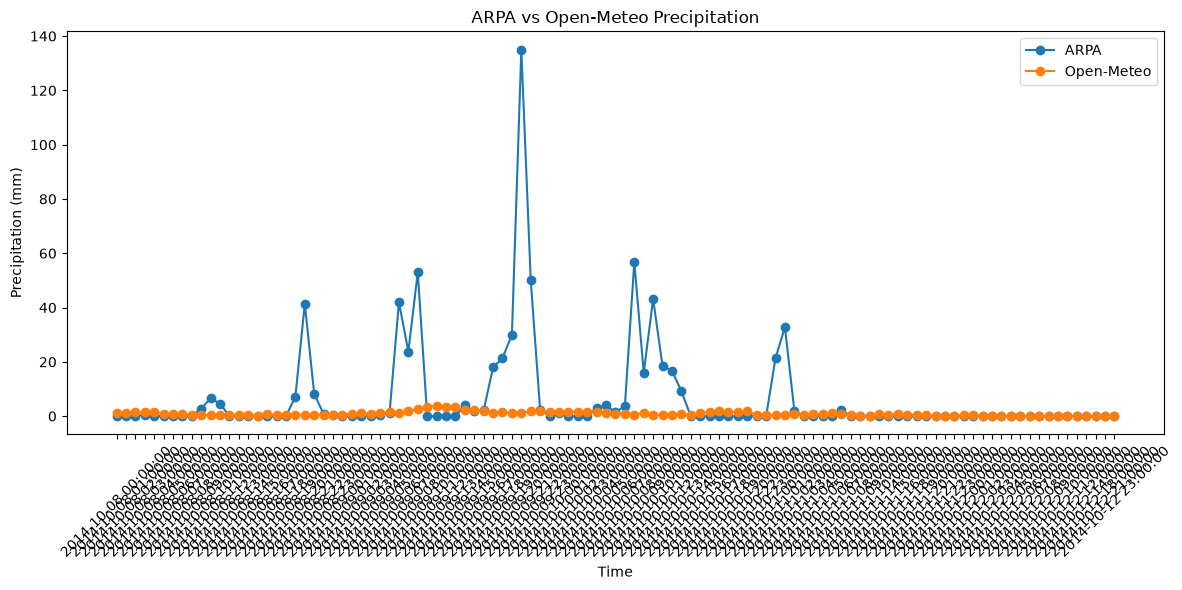

In [40]:
# Compare ARPA and Open-Meteo precipitation

plt.figure(figsize=(12, 6))

plt.plot(
    precipitation["time"],
    precipitation["arpal_precipitation_mm"],
    marker="o",
    label="ARPA"
)

plt.plot(
    precipitation["time"],
    precipitation["openmeteo_precipitation_mm"],
    marker="o",
    label="Open-Meteo"
)

plt.xlabel("Time")
plt.ylabel("Precipitation (mm)")
plt.title("ARPA vs Open-Meteo Precipitation")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# Quantify the difference between ARPA and Open-Meteo

print("Mean absolute error:",
      precipitation["absolute_error_mm"].mean())

print("Maximum absolute error:",
      precipitation["absolute_error_mm"].max())

print("Mean difference:",
      precipitation["difference_mm"].mean())

Mean absolute error: 6.636448598130841
Maximum absolute error: 133.7
Mean difference: 5.55233644859813


In [42]:
# Compare errors with and without the most extreme event

max_error = precipitation["absolute_error_mm"].max()

without_extreme = precipitation[
    precipitation["absolute_error_mm"] < max_error
]

print("MAE including extreme event:",
      precipitation["absolute_error_mm"].mean())

print("MAE excluding extreme event:",
      without_extreme["absolute_error_mm"].mean())

MAE including extreme event: 6.636448598130841
MAE excluding extreme event: 5.437735849056604


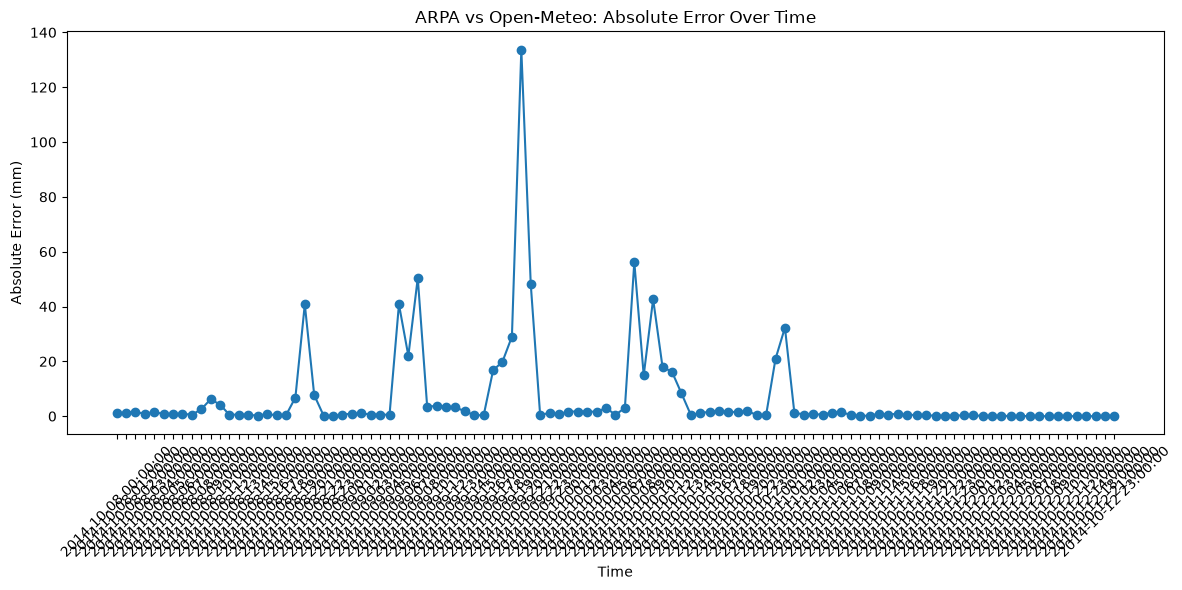

In [43]:
# Absolute error between ARPA and Open-Meteo over time

plt.figure(figsize=(12, 6))

plt.plot(
    precipitation["time"],
    precipitation["absolute_error_mm"],
    marker="o"
)

plt.xlabel("Time")
plt.ylabel("Absolute Error (mm)")
plt.title("ARPA vs Open-Meteo: Absolute Error Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

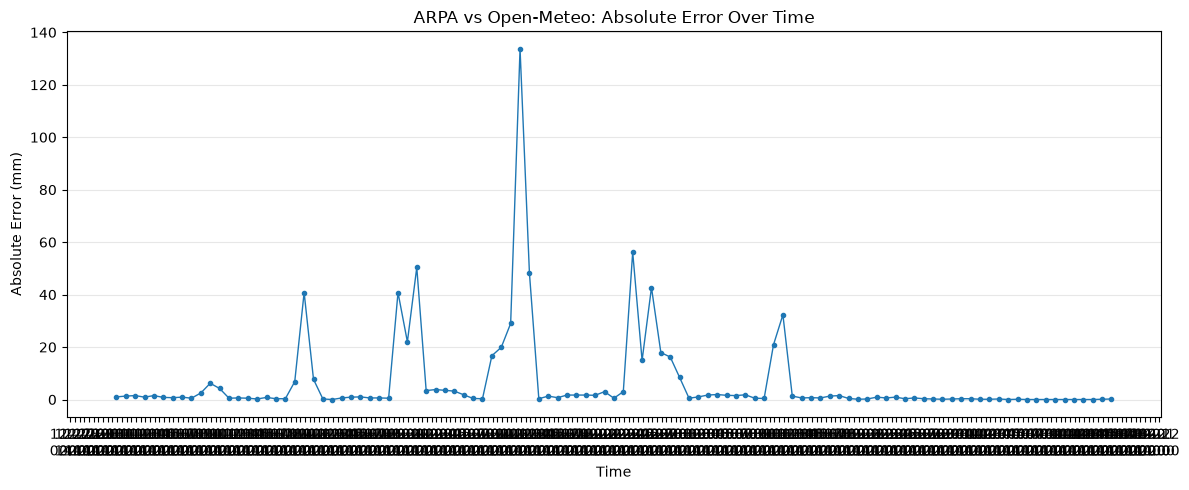

In [44]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))

plt.plot(
    precipitation["time"],
    precipitation["absolute_error_mm"],
    marker="o",
    markersize=3,
    linewidth=1
)

plt.title("ARPA vs Open-Meteo: Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("Absolute Error (mm)")

# Show fewer, cleaner date labels
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

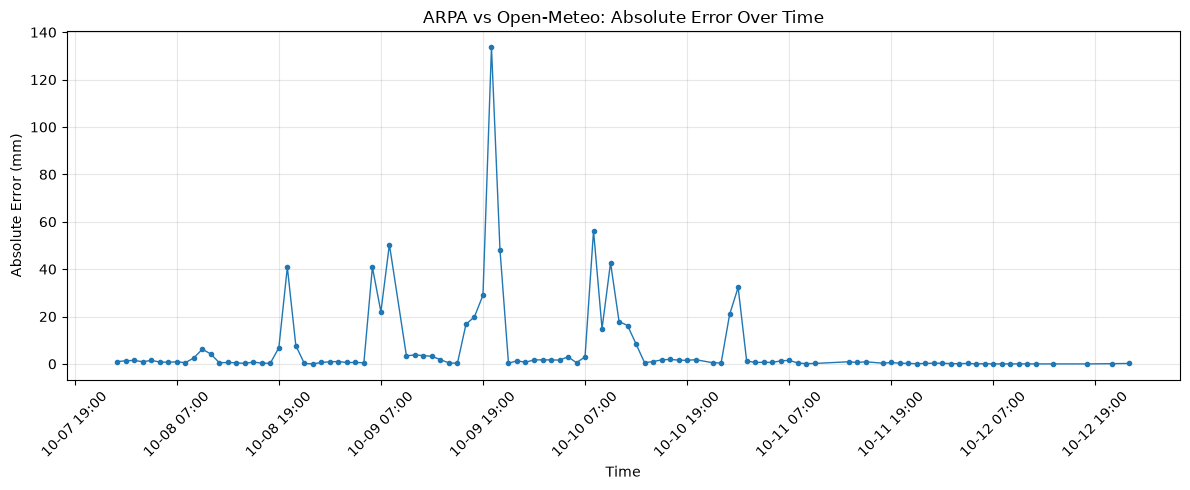

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load precipitation comparison data
precipitation_comparison = pd.read_csv(
    "../data/processed/precipitation_comparison.csv"
)

# Convert time column to datetime
precipitation_comparison["time"] = pd.to_datetime(
    precipitation_comparison["time"]
)

# Create plot
plt.figure(figsize=(12, 5))

plt.plot(
    precipitation_comparison["time"],
    precipitation_comparison["absolute_error_mm"],
    marker="o",
    markersize=3,
    linewidth=1
)

plt.title("ARPA vs Open-Meteo: Absolute Error Over Time")
plt.xlabel("Time")
plt.ylabel("Absolute Error (mm)")

# Clean time axis
ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=12)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%m-%d %H:%M")
)

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Spatial Analysis

The temporal analysis identified extreme rainfall events and periods of large disagreement between ARPA and Open-Meteo precipitation estimates.

The next step is to examine the spatial distribution of rainfall and hazard indicators across Liguria, Italy.

In [46]:
import pandas as pd

# Load processed datasets
extreme_rainfall = pd.read_csv(
    "../data/processed/extreme_rainfall_events.csv"
)

severity_summary = pd.read_csv(
    "../data/processed/severity_summary.csv"
)

print("Extreme rainfall data:")
print(extreme_rainfall.head())

print("\nSeverity summary:")
print(severity_summary)

Extreme rainfall data:
                  time  arpal_precipitation_mm  openmeteo_precipitation_mm  \
0  2014-10-08 20:00:00                    41.4                         0.6   
1  2014-10-09 06:00:00                    42.0                         1.2   
2  2014-10-09 07:00:00                    23.8                         1.8   
3  2014-10-09 08:00:00                    53.0                         2.6   
4  2014-10-09 18:00:00                    21.4                         1.5   

   difference_mm  absolute_error_mm    severity  
0           40.8               40.8       Heavy  
1           40.8               40.8       Heavy  
2           22.0               22.0       Heavy  
3           50.4               50.4  Very Heavy  
4           19.9               19.9       Heavy  

Severity summary:
      severity  hours  max_rainfall  mean_rainfall  mean_openmeteo  \
0  Exceptional      1         135.0     135.000000        1.300000   
1        Heavy      8          43.2      32.00000

In [47]:
import pandas as pd
import os

raw_path = "../data/raw"

print("Raw files:")
print(os.listdir(raw_path))

Raw files:
['40777765150469.csv', 'open-meteo-44.46N8.97E11m.csv', 'README.md']


In [50]:
import pandas as pd

# Load raw ARPA data
arpa_raw = pd.read_csv(
    "../data/raw/40777765150469.csv",
    encoding="latin1",
    sep=None,
    engine="python"
)

print("ARPA raw data loaded successfully!")
print("Shape:", arpa_raw.shape)

print("\nColumns:")
print(arpa_raw.columns.tolist())

display(arpa_raw.head())

ValueError: bad delimiter value

In [51]:
# Inspect the raw ARPA file structure

file_path = "../data/raw/40777765150469.csv"

with open(file_path, "r", encoding="latin1") as f:
    for i in range(15):
        line = f.readline()
        if not line:
            break
        print(f"Line {i+1}:")
        print(repr(line))
        print()

Line 1:
'\n'

Line 2:
'\n'

Line 3:
'"Stazione",GENOVA - GEIRATO\n'

Line 4:
'"Parametro",PRECIPITAZIONE - PRECIPITAZIONE CUMULATA (mm)\n'

Line 5:
'\n'

Line 6:
'"Inizio rilevazione","Fine rilevazione","Valore","Dataset","Valido"\n'

Line 7:
'"08/10/2014 00:00","08/10/2014 01:00","0","Tutti i dati","Sì"\n'

Line 8:
'"08/10/2014 01:00","08/10/2014 02:00","0","Tutti i dati","Sì"\n'

Line 9:
'"08/10/2014 02:00","08/10/2014 03:00","0","Tutti i dati","Sì"\n'

Line 10:
'"08/10/2014 03:00","08/10/2014 04:00",".6","Tutti i dati","Sì"\n'

Line 11:
'"08/10/2014 04:00","08/10/2014 05:00","0","Tutti i dati","Sì"\n'

Line 12:
'"08/10/2014 05:00","08/10/2014 06:00","0","Tutti i dati","Sì"\n'

Line 13:
'"08/10/2014 06:00","08/10/2014 07:00","0","Tutti i dati","Sì"\n'

Line 14:
'"08/10/2014 07:00","08/10/2014 08:00","0","Tutti i dati","Sì"\n'

Line 15:
'"08/10/2014 08:00","08/10/2014 09:00","0","Tutti i dati","Sì"\n'



In [52]:
import pandas as pd

# Load raw ARPA data
arpa_raw = pd.read_csv(
    "../data/raw/40777765150469.csv",
    encoding="latin1",
    skiprows=5
)

# Convert date columns
arpa_raw["Inizio rilevazione"] = pd.to_datetime(
    arpa_raw["Inizio rilevazione"],
    format="%d/%m/%Y %H:%M"
)

arpa_raw["Fine rilevazione"] = pd.to_datetime(
    arpa_raw["Fine rilevazione"],
    format="%d/%m/%Y %H:%M"
)

# Convert precipitation value to numeric
arpa_raw["Valore"] = pd.to_numeric(
    arpa_raw["Valore"],
    errors="coerce"
)

print("ARPA raw data loaded successfully!")

print("\nShape:")
print(arpa_raw.shape)

print("\nColumns:")
print(arpa_raw.columns.tolist())

print("\nData types:")
print(arpa_raw.dtypes)

display(arpa_raw.head())

ValueError: time data "Dati letti" doesn't match format "%d/%m/%Y %H:%M". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [53]:
import pandas as pd

# Load raw ARPA data
arpa_raw = pd.read_csv(
    "../data/raw/40777765150469.csv",
    encoding="latin1",
    skiprows=5,
    header=0,
    on_bad_lines="skip"
)

print("ARPA raw data loaded!")
print("Shape:", arpa_raw.shape)
print("Columns:", arpa_raw.columns.tolist())

# Rename columns to simpler names
arpa_raw = arpa_raw.rename(columns={
    "Inizio rilevazione": "start_time",
    "Fine rilevazione": "end_time",
    "Valore": "value",
    "Dataset": "dataset",
    "Valido": "valid"
})

# Convert date column
arpa_raw["start_time"] = pd.to_datetime(
    arpa_raw["start_time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

# Convert rainfall values to numeric
arpa_raw["value"] = pd.to_numeric(
    arpa_raw["value"],
    errors="coerce"
)

# Remove invalid rows
arpa_raw = arpa_raw.dropna(
    subset=["start_time", "value"]
).copy()

# Sort by time
arpa_raw = arpa_raw.sort_values("start_time").reset_index(drop=True)

print("\nClean ARPA data:")
print(arpa_raw.head())

print("\nFinal shape:", arpa_raw.shape)

print("\nDate range:")
print(arpa_raw["start_time"].min())
print(arpa_raw["start_time"].max())

ARPA raw data loaded!
Shape: (109, 5)
Columns: ['Inizio rilevazione', 'Fine rilevazione', 'Valore', 'Dataset', 'Valido']

Clean ARPA data:
           start_time          end_time  value       dataset valid
0 2014-10-08 00:00:00  08/10/2014 01:00    0.0  Tutti i dati    Sì
1 2014-10-08 01:00:00  08/10/2014 02:00    0.0  Tutti i dati    Sì
2 2014-10-08 02:00:00  08/10/2014 03:00    0.0  Tutti i dati    Sì
3 2014-10-08 03:00:00  08/10/2014 04:00    0.6  Tutti i dati    Sì
4 2014-10-08 04:00:00  08/10/2014 05:00    0.0  Tutti i dati    Sì

Final shape: (107, 5)

Date range:
2014-10-08 00:00:00
2014-10-12 23:00:00


In [56]:
import pandas as pd

# Load Open-Meteo raw data correctly
openmeteo_raw = pd.read_csv(
    "../data/raw/open-meteo-44.46N8.97E11m.csv",
    skiprows=6
)

print("Open-Meteo raw data loaded!")

print("\nShape:")
print(openmeteo_raw.shape)

print("\nColumns:")
print(openmeteo_raw.columns.tolist())

print("\nFirst 5 rows:")
display(openmeteo_raw.head())

print("\nData types:")
print(openmeteo_raw.dtypes)

Open-Meteo raw data loaded!

Shape:
(117, 7)

Columns:
['2014-10-08T02:00', '16.9', '97', '1.50', '1.50.1', '2.9', '1017.9']

First 5 rows:


,2014-10-08T02:00,16.9,97,1.50,1.50.1,2.9,1017.9
0,2014-10-08T03:00,16.6,98,1.5,1.5,4.1,1017.4
1,2014-10-08T04:00,16.6,98,1.5,1.5,3.8,1017.2
2,2014-10-08T05:00,16.5,99,0.8,0.8,3.7,1017.0
3,2014-10-08T06:00,16.7,98,0.7,0.7,4.2,1016.7
4,2014-10-08T07:00,16.9,98,0.9,0.9,4.6,1017.0



Data types:
2014-10-08T02:00        str
16.9                float64
97                    int64
1.50                float64
1.50.1              float64
2.9                 float64
1017.9              float64
dtype: object


In [57]:
# Inspect the first lines of the Open-Meteo file

file_path = "../data/raw/open-meteo-44.46N8.97E11m.csv"

with open(file_path, "r", encoding="utf-8") as f:
    for i in range(20):
        line = f.readline()
        print(f"Line {i+1}: {repr(line)}")

Line 1: 'latitude,longitude,elevation,utc_offset_seconds,timezone,timezone_abbreviation\n'
Line 2: '44.46397,8.972392,11.0,7200,Europe/Rome,GMT+2\n'
Line 3: '\n'
Line 4: 'time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),rain (mm),wind_speed_10m (km/h),pressure_msl (hPa)\n'
Line 5: '2014-10-08T00:00,17.1,96,1.00,1.00,2.1,1017.4\n'
Line 6: '2014-10-08T01:00,17.0,97,1.30,1.30,3.1,1017.8\n'
Line 7: '2014-10-08T02:00,16.9,97,1.50,1.50,2.9,1017.9\n'
Line 8: '2014-10-08T03:00,16.6,98,1.50,1.50,4.1,1017.4\n'
Line 9: '2014-10-08T04:00,16.6,98,1.50,1.50,3.8,1017.2\n'
Line 10: '2014-10-08T05:00,16.5,99,0.80,0.80,3.7,1017.0\n'
Line 11: '2014-10-08T06:00,16.7,98,0.70,0.70,4.2,1016.7\n'
Line 12: '2014-10-08T07:00,16.9,98,0.90,0.90,4.6,1017.0\n'
Line 13: '2014-10-08T08:00,17.2,98,0.50,0.50,4.9,1017.2\n'
Line 14: '2014-10-08T09:00,17.6,96,0.30,0.30,3.6,1017.8\n'
Line 15: '2014-10-08T10:00,18.2,94,0.40,0.40,3.9,1018.1\n'
Line 16: '2014-10-08T11:00,18.6,93,0.40,0.40,5.0,1018.5\n'
Lin

In [58]:
import pandas as pd

# Load Open-Meteo raw data
openmeteo_raw = pd.read_csv(
    "../data/raw/open-meteo-44.46N8.97E11m.csv",
    skiprows=3
)

print("Open-Meteo data loaded!")
print("Shape:", openmeteo_raw.shape)

print("\nColumns:")
print(openmeteo_raw.columns.tolist())

print("\nFirst 5 rows:")
print(openmeteo_raw.head())

print("\nData types:")
print(openmeteo_raw.dtypes)

Open-Meteo data loaded!
Shape: (120, 7)

Columns:
['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'rain (mm)', 'wind_speed_10m (km/h)', 'pressure_msl (hPa)']

First 5 rows:
               time  temperature_2m (°C)  relative_humidity_2m (%)  \
0  2014-10-08T00:00                 17.1                        96   
1  2014-10-08T01:00                 17.0                        97   
2  2014-10-08T02:00                 16.9                        97   
3  2014-10-08T03:00                 16.6                        98   
4  2014-10-08T04:00                 16.6                        98   

   precipitation (mm)  rain (mm)  wind_speed_10m (km/h)  pressure_msl (hPa)  
0                 1.0        1.0                    2.1              1017.4  
1                 1.3        1.3                    3.1              1017.8  
2                 1.5        1.5                    2.9              1017.9  
3                 1.5        1.5                    4.1     

In [59]:
# Clean Open-Meteo data

# Convert time to datetime
openmeteo_raw["time"] = pd.to_datetime(
    openmeteo_raw["time"],
    errors="coerce"
)

# Rename precipitation column
openmeteo_raw = openmeteo_raw.rename(columns={
    "precipitation (mm)": "openmeteo_precipitation_mm",
    "temperature_2m (°C)": "temperature_c",
    "relative_humidity_2m (%)": "humidity_percent",
    "rain (mm)": "rain_mm",
    "wind_speed_10m (km/h)": "wind_speed_kmh",
    "pressure_msl (hPa)": "pressure_hpa"
})

# Remove rows with invalid time
openmeteo_raw = openmeteo_raw.dropna(
    subset=["time"]
).copy()

# Sort by time
openmeteo_raw = openmeteo_raw.sort_values(
    "time"
).reset_index(drop=True)

print("Clean Open-Meteo data:")
print(openmeteo_raw.head())

print("\nFinal shape:", openmeteo_raw.shape)

print("\nDate range:")
print(openmeteo_raw["time"].min())
print(openmeteo_raw["time"].max())

Clean Open-Meteo data:
                 time  temperature_c  humidity_percent  \
0 2014-10-08 00:00:00           17.1                96   
1 2014-10-08 01:00:00           17.0                97   
2 2014-10-08 02:00:00           16.9                97   
3 2014-10-08 03:00:00           16.6                98   
4 2014-10-08 04:00:00           16.6                98   

   openmeteo_precipitation_mm  rain_mm  wind_speed_kmh  pressure_hpa  
0                         1.0      1.0             2.1        1017.4  
1                         1.3      1.3             3.1        1017.8  
2                         1.5      1.5             2.9        1017.9  
3                         1.5      1.5             4.1        1017.4  
4                         1.5      1.5             3.8        1017.2  

Final shape: (120, 7)

Date range:
2014-10-08 00:00:00
2014-10-12 23:00:00


In [2]:
import pandas as pd

# Load ARPA raw data
arpa_raw = pd.read_csv(
    "../data/raw/40777765150469.csv",
    encoding="latin1",
    skiprows=5,
    header=0,
    on_bad_lines="skip"
)

# Rename columns
arpa_raw = arpa_raw.rename(columns={
    "Inizio rilevazione": "start_time",
    "Fine rilevazione": "end_time",
    "Valore": "value",
    "Dataset": "dataset",
    "Valido": "valid"
})

# Convert data types
arpa_raw["start_time"] = pd.to_datetime(
    arpa_raw["start_time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

arpa_raw["value"] = pd.to_numeric(
    arpa_raw["value"],
    errors="coerce"
)

# Remove invalid rows
arpa_raw = arpa_raw.dropna(
    subset=["start_time", "value"]
).copy()

# Sort by time
arpa_raw = arpa_raw.sort_values(
    "start_time"
).reset_index(drop=True)

print("ARPA data loaded successfully!")
print("Shape:", arpa_raw.shape)

print("\nDate range:")
print(arpa_raw["start_time"].min())
print(arpa_raw["start_time"].max())

print("\nFirst 5 rows:")
display(arpa_raw.head())

ARPA data loaded successfully!
Shape: (107, 5)

Date range:
2014-10-08 00:00:00
2014-10-12 23:00:00

First 5 rows:


,start_time,end_time,value,dataset,valid
0,2014-10-08 00:00:00,08/10/2014 01:00,0.0,Tutti i dati,Sì
1,2014-10-08 01:00:00,08/10/2014 02:00,0.0,Tutti i dati,Sì
2,2014-10-08 02:00:00,08/10/2014 03:00,0.0,Tutti i dati,Sì
3,2014-10-08 03:00:00,08/10/2014 04:00,0.6,Tutti i dati,Sì
4,2014-10-08 04:00:00,08/10/2014 05:00,0.0,Tutti i dati,Sì


In [4]:
# Load and clean Open-Meteo data

openmeteo_raw = pd.read_csv(
    "../data/raw/open-meteo-44.46N8.97E11m.csv",
    skiprows=3
)

openmeteo_raw["time"] = pd.to_datetime(
    openmeteo_raw["time"],
    errors="coerce"
)

openmeteo_raw = openmeteo_raw.rename(columns={
    "precipitation (mm)": "openmeteo_precipitation_mm",
    "temperature_2m (°C)": "temperature_c",
    "relative_humidity_2m (%)": "humidity_percent",
    "rain (mm)": "rain_mm",
    "wind_speed_10m (km/h)": "wind_speed_kmh",
    "pressure_msl (hPa)": "pressure_hpa"
})

openmeteo_raw = openmeteo_raw.dropna(
    subset=["time"]
).copy()

openmeteo_raw = openmeteo_raw.sort_values(
    "time"
).reset_index(drop=True)

print("Open-Meteo data loaded successfully!")
print("Shape:", openmeteo_raw.shape)

print("\nDate range:")
print(openmeteo_raw["time"].min())
print(openmeteo_raw["time"].max())

print("\nFirst 5 rows:")
display(openmeteo_raw.head())

Open-Meteo data loaded successfully!
Shape: (120, 7)

Date range:
2014-10-08 00:00:00
2014-10-12 23:00:00

First 5 rows:


,time,temperature_c,humidity_percent,openmeteo_precipitation_mm,rain_mm,wind_speed_kmh,pressure_hpa
0,2014-10-08 00:00:00,17.1,96,1.0,1.0,2.1,1017.4
1,2014-10-08 01:00:00,17.0,97,1.3,1.3,3.1,1017.8
2,2014-10-08 02:00:00,16.9,97,1.5,1.5,2.9,1017.9
3,2014-10-08 03:00:00,16.6,98,1.5,1.5,4.1,1017.4
4,2014-10-08 04:00:00,16.6,98,1.5,1.5,3.8,1017.2


In [5]:
# Merge ARPA and Open-Meteo by timestamp

merged_data = pd.merge(
    arpa_raw[["start_time", "value"]],
    openmeteo_raw[["time", "openmeteo_precipitation_mm"]],
    left_on="start_time",
    right_on="time",
    how="inner"
)

# Rename ARPA precipitation column
merged_data = merged_data.rename(columns={
    "value": "arpal_precipitation_mm"
})

# Remove duplicate time column
merged_data = merged_data.drop(columns=["time"])

print("Merged dataset created successfully!")
print("Shape:", merged_data.shape)

print("\nColumns:")
print(merged_data.columns.tolist())

print("\nFirst 10 rows:")
display(merged_data.head(10))

Merged dataset created successfully!
Shape: (107, 3)

Columns:
['start_time', 'arpal_precipitation_mm', 'openmeteo_precipitation_mm']

First 10 rows:


,start_time,arpal_precipitation_mm,openmeteo_precipitation_mm
0,2014-10-08 00:00:00,0.0,1.0
1,2014-10-08 01:00:00,0.0,1.3
2,2014-10-08 02:00:00,0.0,1.5
3,2014-10-08 03:00:00,0.6,1.5
4,2014-10-08 04:00:00,0.0,1.5
5,2014-10-08 05:00:00,0.0,0.8
6,2014-10-08 06:00:00,0.0,0.7
7,2014-10-08 07:00:00,0.0,0.9
8,2014-10-08 08:00:00,0.0,0.5
9,2014-10-08 09:00:00,2.8,0.3


In [6]:
# Calculate precipitation difference between ARPA and Open-Meteo

merged_data["difference_mm"] = (
    merged_data["arpal_precipitation_mm"]
    - merged_data["openmeteo_precipitation_mm"]
)

merged_data["absolute_error_mm"] = (
    merged_data["difference_mm"].abs()
)

print("Difference calculations completed!")

print("\nFirst 10 rows:")
display(merged_data.head(10))

print("\nSummary:")
print(merged_data[
    [
        "arpal_precipitation_mm",
        "openmeteo_precipitation_mm",
        "difference_mm",
        "absolute_error_mm"
    ]
].describe())

Difference calculations completed!

First 10 rows:


,start_time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm
0,2014-10-08 00:00:00,0.0,1.0,-1.0,1.0
1,2014-10-08 01:00:00,0.0,1.3,-1.3,1.3
2,2014-10-08 02:00:00,0.0,1.5,-1.5,1.5
3,2014-10-08 03:00:00,0.6,1.5,-0.9,0.9
4,2014-10-08 04:00:00,0.0,1.5,-1.5,1.5
5,2014-10-08 05:00:00,0.0,0.8,-0.8,0.8
6,2014-10-08 06:00:00,0.0,0.7,-0.7,0.7
7,2014-10-08 07:00:00,0.0,0.9,-0.9,0.9
8,2014-10-08 08:00:00,0.0,0.5,-0.5,0.5
9,2014-10-08 09:00:00,2.8,0.3,2.5,2.5



Summary:
       arpal_precipitation_mm  openmeteo_precipitation_mm  difference_mm  \
count              107.000000                  107.000000     107.000000   
mean                 6.456075                    0.903738       5.552336   
std                 17.553945                    0.791097      17.483072   
min                  0.000000                    0.000000      -3.800000   
25%                  0.000000                    0.300000      -0.750000   
50%                  0.000000                    0.700000      -0.200000   
75%                  2.200000                    1.350000       1.400000   
max                135.000000                    3.800000     133.700000   

       absolute_error_mm  
count         107.000000  
mean            6.636449  
std            17.097343  
min             0.000000  
25%             0.300000  
50%             0.800000  
75%             2.750000  
max           133.700000  


In [7]:
# Identify the largest differences between ARPA and Open-Meteo

largest_errors = merged_data.sort_values(
    by="absolute_error_mm",
    ascending=False
).head(10)

print("Top 10 largest differences:")

display(
    largest_errors[
        [
            "start_time",
            "arpal_precipitation_mm",
            "openmeteo_precipitation_mm",
            "difference_mm",
            "absolute_error_mm"
        ]
    ]
)

Top 10 largest differences:


,start_time,arpal_precipitation_mm,openmeteo_precipitation_mm,difference_mm,absolute_error_mm
43,2014-10-09 20:00:00,135.0,1.3,133.7,133.7
55,2014-10-10 08:00:00,56.8,0.6,56.2,56.2
32,2014-10-09 08:00:00,53.0,2.6,50.4,50.4
44,2014-10-09 21:00:00,50.0,1.8,48.2,48.2
57,2014-10-10 10:00:00,43.2,0.5,42.7,42.7
20,2014-10-08 20:00:00,41.4,0.6,40.8,40.8
30,2014-10-09 06:00:00,42.0,1.2,40.8,40.8
71,2014-10-11 01:00:00,32.8,0.5,32.3,32.3
42,2014-10-09 19:00:00,30.0,1.0,29.0,29.0
31,2014-10-09 07:00:00,23.8,1.8,22.0,22.0


## Station Location

The rainfall observations are associated with the ARPA Liguria station GENOVA - GEIRATO.

The station location will be used as the spatial reference for mapping the observed rainfall event and comparing it with gridded meteorological data.

## Municipal Spatial Context

To provide local spatial context for the GENOVA - GEIRATO rainfall station, a 10 km spatial buffer was applied around the station.

The analysis identified 13 municipalities that are within or intersect the 10 km spatial context.

This spatial context is used to identify nearby administrative areas potentially relevant to the observed extreme rainfall event. Since rainfall observations are available from a single station, the results should be interpreted as a station-based hazard context rather than a municipality-level rainfall distribution.

In [1]:
import geopandas as gpd
from shapely.geometry import Point

print("GeoPandas:", gpd.__version__)
print("GeoPandas is working!")

GeoPandas: 1.1.4
GeoPandas is working!


In [2]:
# Create ARPA GENOVA - GEIRATO station GeoDataFrame

station_lat = 44.45966
station_lon = 8.97959
station_elevation = 58

station_gdf = gpd.GeoDataFrame(
    {
        "station": ["GENOVA - GEIRATO"],
        "latitude": [station_lat],
        "longitude": [station_lon],
        "elevation_m": [station_elevation]
    },
    geometry=[Point(station_lon, station_lat)],
    crs="EPSG:4326"
)

print("Station GeoDataFrame created successfully!")

display(station_gdf)

Station GeoDataFrame created successfully!


,station,latitude,longitude,elevation_m,geometry
0,GENOVA - GEIRATO,44.45966,8.97959,58,POINT (8.97959 44.45966)


NameError: name 'plt' is not defined

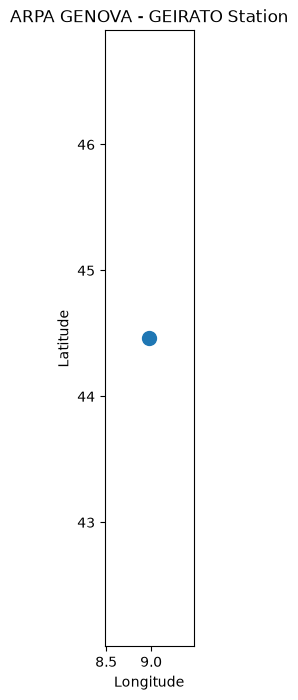

In [3]:
# Plot the ARPA station

ax = station_gdf.plot(
    figsize=(8, 8),
    markersize=100
)

ax.set_title("ARPA GENOVA - GEIRATO Station")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [4]:
import matplotlib.pyplot as plt

print("Matplotlib is working!")

Matplotlib is working!


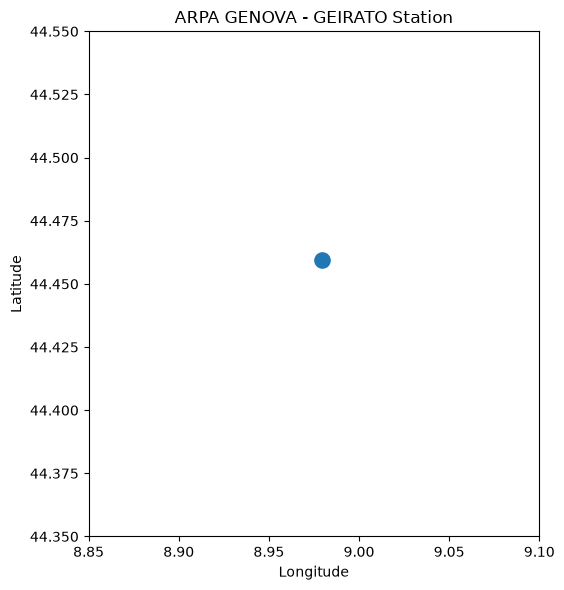

In [5]:
# Plot the ARPA station with a focused map extent

fig, ax = plt.subplots(figsize=(8, 6))

station_gdf.plot(
    ax=ax,
    markersize=120
)

ax.set_xlim(8.85, 9.10)
ax.set_ylim(44.35, 44.55)

ax.set_title("ARPA GENOVA - GEIRATO Station")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [6]:
import geopandas as gpd

liguria = gpd.read_file("../data/raw/Regione.shp")

print(liguria.shape)
print(liguria.columns)
print(liguria.crs)

(10, 11)
Index(['ogr_fid', 'id', 'nome', 'cod_reg_is', 'sup_kmq_is', 'sup_ha_ist',
       'pop_res_20', 'dens_abita', 'area_kmq_g', 'area_ha_gi', 'geometry'],
      dtype='str')
EPSG:7791


In [7]:
print(liguria[["nome", "geometry"]])

      nome                                           geometry
0  LIGURIA  POLYGON Z ((483689.937 4917650.04 0, 483330.76...
1  LIGURIA  POLYGON Z ((393195.158 4847813.551 0, 393190.6...
2  LIGURIA  POLYGON Z ((437982.201 4874704.836 0, 437971.6...
3  LIGURIA  POLYGON Z ((568212.379 4874803.741 0, 568207.7...
4  LIGURIA  POLYGON Z ((568315.047 4874987.468 0, 568305.7...
5  LIGURIA  POLYGON Z ((567869.117 4875925.96 0, 567869.64...
6  LIGURIA  POLYGON Z ((568538.169 4879859.697 0, 568534.8...
7  LIGURIA  POLYGON Z ((455659.475 4897966.374 0, 455640.9...
8  LIGURIA  POLYGON Z ((495073.596 4915035.568 0, 494462.5...
9  LIGURIA  POLYGON Z ((490492.072 4916254.538 0, 489964.3...


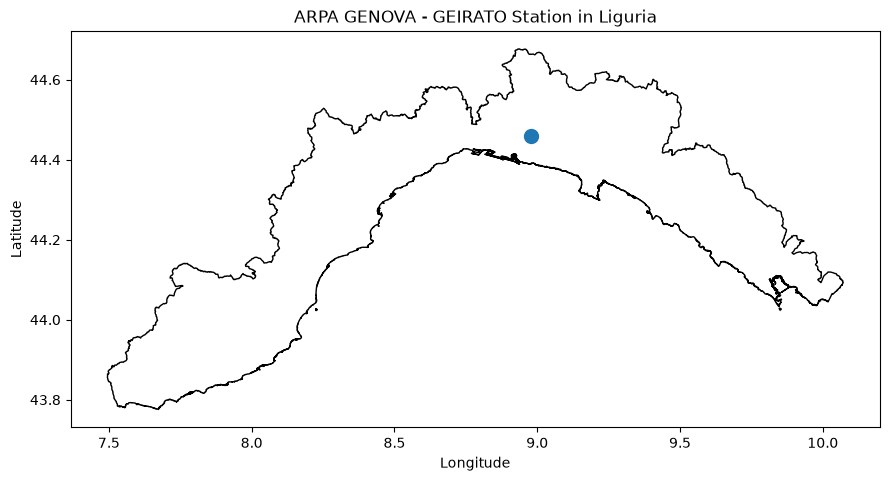

In [8]:
# Convert Liguria boundary to geographic coordinates
liguria_wgs84 = liguria.to_crs("EPSG:4326")

# Convert station coordinates to the same CRS
station_wgs84 = station_gdf.to_crs("EPSG:4326")

# Plot Liguria and the ARPA station
fig, ax = plt.subplots(figsize=(9, 8))

liguria_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

station_wgs84.plot(
    ax=ax,
    markersize=100
)

ax.set_title("ARPA GENOVA - GEIRATO Station in Liguria")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [9]:
print(liguria_wgs84.total_bounds)

[ 7.49480079 43.77567171 10.07152817 44.6769282 ]


In [11]:
import pandas as pd

arpa_raw = pd.read_csv(
    "../data/raw/40777765150469.csv",
    encoding="latin1",
    skiprows=5,
    header=0,
    on_bad_lines="skip"
)

arpa_raw = arpa_raw.rename(columns={
    "Inizio rilevazione": "start_time",
    "Fine rilevazione": "end_time",
    "Valore": "value",
    "Dataset": "dataset",
    "Valido": "valid"
})

arpa_raw["start_time"] = pd.to_datetime(
    arpa_raw["start_time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

arpa_raw["value"] = pd.to_numeric(
    arpa_raw["value"],
    errors="coerce"
)

arpa_raw = arpa_raw.dropna(
    subset=["start_time", "value"]
).copy()

arpa_raw = arpa_raw.sort_values(
    "start_time"
).reset_index(drop=True)

print("Rows:", len(arpa_raw))
print("Maximum rainfall:", arpa_raw["value"].max(), "mm")

Rows: 107
Maximum rainfall: 135.0 mm


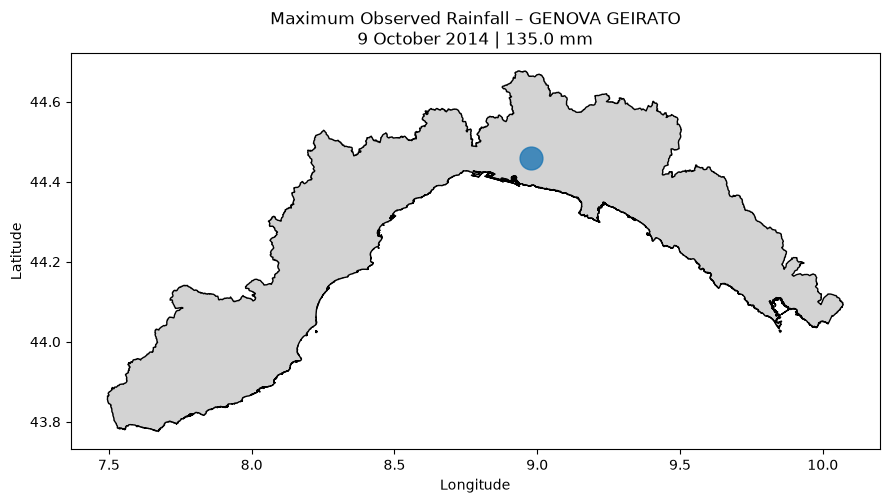

In [13]:
# Calculate maximum observed rainfall
max_rainfall = arpa_raw["value"].max()

# Create station hazard data
hazard_station = station_wgs84.copy()
hazard_station["rainfall_mm"] = max_rainfall

# Plot hazard map
fig, ax = plt.subplots(figsize=(9, 8))

# Liguria boundary
liguria_wgs84.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1
)

# Rainfall station
hazard_station.plot(
    ax=ax,
    markersize=max_rainfall * 2,
    alpha=0.8
)

ax.set_title(
    f"Maximum Observed Rainfall – GENOVA GEIRATO\n"
    f"9 October 2014 | {max_rainfall:.1f} mm"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

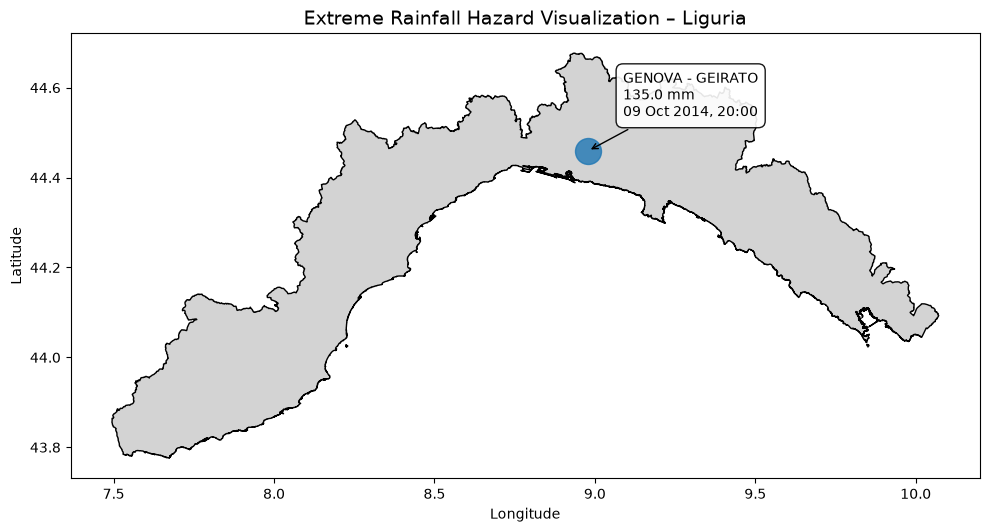

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load ARPA rainfall data
arpa_raw = pd.read_csv(
    "../data/raw/40777765150469.csv",
    encoding="latin1",
    skiprows=5,
    header=0,
    on_bad_lines="skip"
)

arpa_raw = arpa_raw.rename(columns={
    "Inizio rilevazione": "start_time",
    "Valore": "value"
})

arpa_raw["start_time"] = pd.to_datetime(
    arpa_raw["start_time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

arpa_raw["value"] = pd.to_numeric(
    arpa_raw["value"],
    errors="coerce"
)

arpa_raw = arpa_raw.dropna(
    subset=["start_time", "value"]
).copy()

# Find maximum rainfall event
max_event = arpa_raw.loc[arpa_raw["value"].idxmax()]
max_rainfall = max_event["value"]

# Load Liguria boundary
liguria = gpd.read_file("../data/raw/Regione.shp")
liguria_wgs84 = liguria.to_crs("EPSG:4326")

# Create station
station_gdf = gpd.GeoDataFrame(
    {
        "station": ["GENOVA - GEIRATO"],
        "rainfall_mm": [max_rainfall]
    },
    geometry=[Point(8.97959, 44.45966)],
    crs="EPSG:4326"
)

# Create map
fig, ax = plt.subplots(figsize=(10, 8))

liguria_wgs84.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1
)

station_gdf.plot(
    ax=ax,
    markersize=350,
    alpha=0.8
)

# Station coordinates
x = station_gdf.geometry.x.iloc[0]
y = station_gdf.geometry.y.iloc[0]

# Add annotation
ax.annotate(
    f"GENOVA - GEIRATO\n"
    f"{max_rainfall:.1f} mm\n"
    f"{max_event['start_time'].strftime('%d %b %Y, %H:%M')}",
    xy=(x, y),
    xytext=(25, 25),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        alpha=0.9
    ),
    arrowprops=dict(arrowstyle="->")
)

ax.set_title(
    "Extreme Rainfall Hazard Visualization – Liguria",
    fontsize=14
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

arpa_raw = pd.read_csv(
    "../data/raw/40777765150469.csv",
    encoding="latin1",
    skiprows=5,
    header=0,
    on_bad_lines="skip"
)

arpa_raw = arpa_raw.rename(columns={
    "Inizio rilevazione": "start_time",
    "Fine rilevazione": "end_time",
    "Valore": "value",
    "Dataset": "dataset",
    "Valido": "valid"
})

arpa_raw["start_time"] = pd.to_datetime(
    arpa_raw["start_time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

arpa_raw["value"] = pd.to_numeric(
    arpa_raw["value"],
    errors="coerce"
)

arpa_raw = arpa_raw.dropna(
    subset=["start_time", "value"]
).copy()

arpa_raw = arpa_raw.sort_values(
    "start_time"
).reset_index(drop=True)

print("ARPA data:", arpa_raw.shape)
print("Maximum rainfall:", arpa_raw["value"].max(), "mm")

ARPA data: (107, 5)
Maximum rainfall: 135.0 mm


In [3]:
max_event = arpa_raw.loc[
    arpa_raw["value"].idxmax()
]

print("Maximum rainfall event:")
print(max_event)

Maximum rainfall event:
start_time    2014-10-09 20:00:00
end_time         09/10/2014 21:00
value                       135.0
dataset              Tutti i dati
valid                          Sì
Name: 43, dtype: object


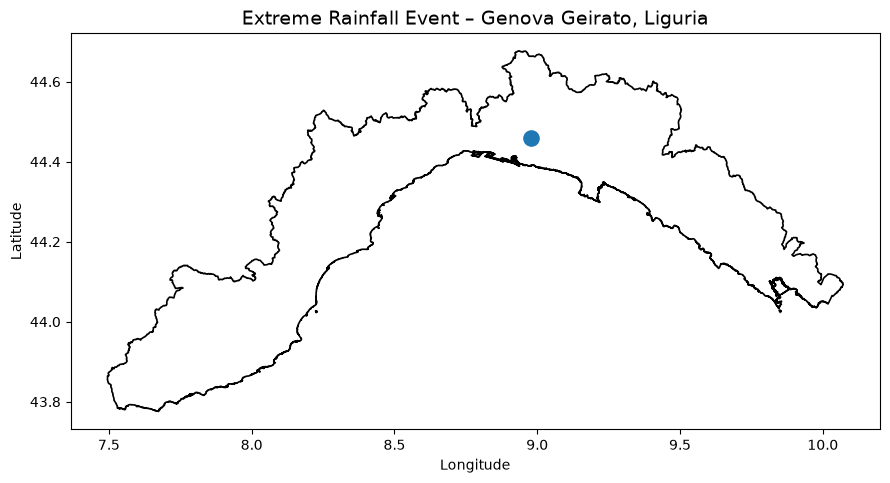

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load Liguria regional boundary
liguria = gpd.read_file("../data/raw/Regione.shp")

# Reproject to WGS84
liguria_wgs84 = liguria.to_crs("EPSG:4326")

# GENOVA - GEIRATO station coordinates
station_gdf = gpd.GeoDataFrame(
    {
        "station": ["GENOVA - GEIRATO"],
        "rainfall_mm": [135.0],
        "date": ["2014-10-09 20:00"]
    },
    geometry=[Point(8.97959, 44.45966)],
    crs="EPSG:4326"
)

# Plot
fig, ax = plt.subplots(figsize=(9, 8))

liguria_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2
)

station_gdf.plot(
    ax=ax,
    markersize=120
)

ax.set_title(
    "Extreme Rainfall Event – Genova Geirato, Liguria",
    fontsize=14
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

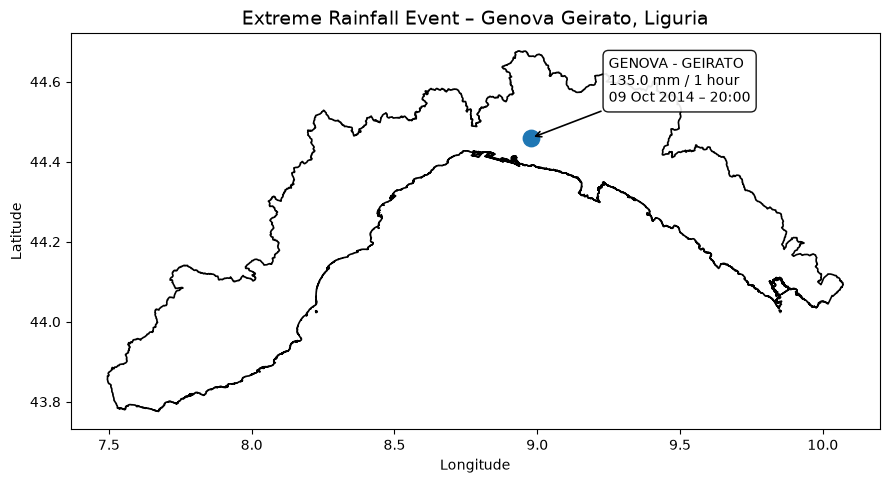

In [5]:
fig, ax = plt.subplots(figsize=(9, 8))

# Liguria boundary
liguria_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2
)

# Station
station_gdf.plot(
    ax=ax,
    markersize=140
)

# Event annotation
ax.annotate(
    "GENOVA - GEIRATO\n135.0 mm / 1 hour\n09 Oct 2014 – 20:00",
    xy=(8.97959, 44.45966),
    xytext=(9.25, 44.55),
    arrowprops=dict(arrowstyle="->", linewidth=1.2),
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9)
)

ax.set_title(
    "Extreme Rainfall Event – Genova Geirato, Liguria",
    fontsize=14
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [6]:
# Calculate the geographic center of Liguria
liguria_centroid = liguria_wgs84.geometry.union_all().centroid

# Create a GeoDataFrame for the centroid
centroid_gdf = gpd.GeoDataFrame(
    {
        "location": ["Liguria centroid"]
    },
    geometry=[liguria_centroid],
    crs="EPSG:4326"
)

print("Liguria centroid:")
print(liguria_centroid)

Liguria centroid:
POINT (8.70467133019246 44.26478290084453)


In [7]:
# Reproject to a metric CRS
liguria_metric = liguria_wgs84.to_crs("EPSG:32632")
station_metric = station_gdf.to_crs("EPSG:32632")
centroid_metric = centroid_gdf.to_crs("EPSG:32632")

# Calculate distance in kilometers
distance_km = (
    station_metric.geometry.iloc[0]
    .distance(centroid_metric.geometry.iloc[0])
    / 1000
)

print(f"Distance from GENOVA - GEIRATO to Liguria centroid: {distance_km:.2f} km")

Distance from GENOVA - GEIRATO to Liguria centroid: 30.80 km


In [8]:
# Calculate rolling rainfall accumulations

rainfall = arpa_raw[["start_time", "value"]].copy()

rainfall = rainfall.set_index("start_time")

# Rolling rainfall accumulation
rainfall["rain_1h_mm"] = rainfall["value"].rolling("1h").sum()
rainfall["rain_3h_mm"] = rainfall["value"].rolling("3h").sum()
rainfall["rain_6h_mm"] = rainfall["value"].rolling("6h").sum()

# Find maximum accumulation for each duration
max_1h = rainfall["rain_1h_mm"].max()
max_3h = rainfall["rain_3h_mm"].max()
max_6h = rainfall["rain_6h_mm"].max()

print(f"Maximum 1-hour rainfall: {max_1h:.1f} mm")
print(f"Maximum 3-hour rainfall: {max_3h:.1f} mm")
print(f"Maximum 6-hour rainfall: {max_6h:.1f} mm")

Maximum 1-hour rainfall: 135.0 mm
Maximum 3-hour rainfall: 215.0 mm
Maximum 6-hour rainfall: 256.6 mm


In [9]:
# Find the times of maximum cumulative rainfall

max_3h_time = rainfall["rain_3h_mm"].idxmax()
max_6h_time = rainfall["rain_6h_mm"].idxmax()

print("Maximum 3-hour accumulation:")
print(max_3h_time)
print(f"Rainfall: {rainfall.loc[max_3h_time, 'rain_3h_mm']:.1f} mm")

print("\nMaximum 6-hour accumulation:")
print(max_6h_time)
print(f"Rainfall: {rainfall.loc[max_6h_time, 'rain_6h_mm']:.1f} mm")

Maximum 3-hour accumulation:
2014-10-09 21:00:00
Rainfall: 215.0 mm

Maximum 6-hour accumulation:
2014-10-09 21:00:00
Rainfall: 256.6 mm


In [10]:
# Inspect rainfall around the main extreme event

event_window = rainfall.loc[
    "2014-10-09 15:00":"2014-10-09 23:00"
]

print(event_window[
    ["value", "rain_1h_mm", "rain_3h_mm", "rain_6h_mm"]
])

                     value  rain_1h_mm  rain_3h_mm  rain_6h_mm
start_time                                                    
2014-10-09 15:00:00    1.8         1.8         5.8         5.8
2014-10-09 16:00:00    2.2         2.2         8.0         8.0
2014-10-09 17:00:00   18.0        18.0        22.0        26.0
2014-10-09 18:00:00   21.4        21.4        41.6        47.4
2014-10-09 19:00:00   30.0        30.0        69.4        77.4
2014-10-09 20:00:00  135.0       135.0       186.4       208.4
2014-10-09 21:00:00   50.0        50.0       215.0       256.6
2014-10-09 22:00:00    2.2         2.2       187.2       256.6
2014-10-09 23:00:00    0.2         0.2        52.4       238.8


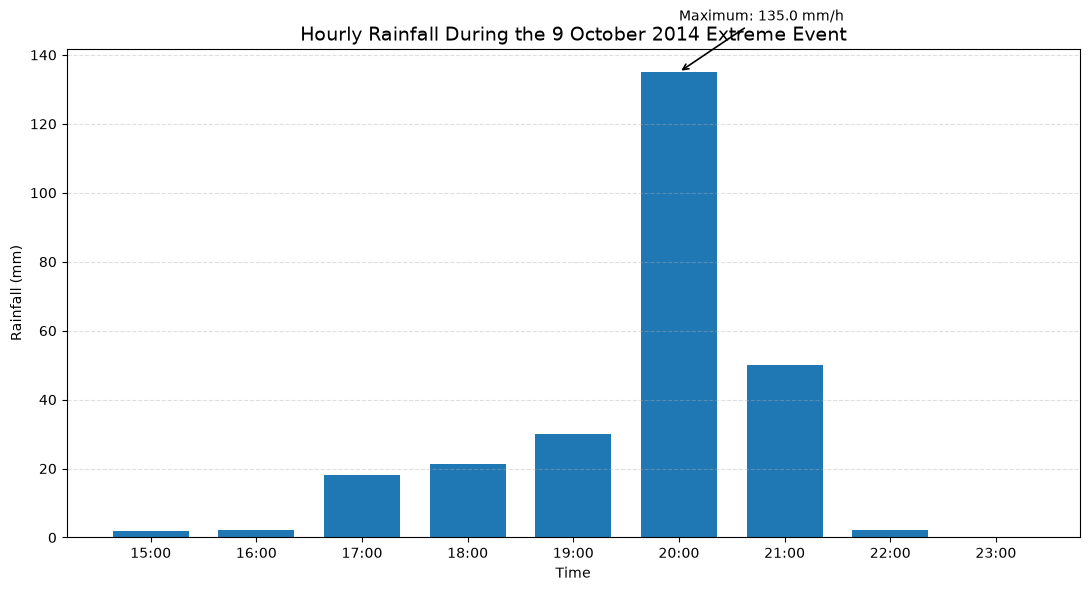

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(11, 6))

# Plot hourly rainfall
ax.bar(
    event_window.index,
    event_window["value"],
    width=0.03
)

# Highlight the maximum rainfall event
max_time = event_window["value"].idxmax()
max_value = event_window["value"].max()

ax.annotate(
    f"Maximum: {max_value:.1f} mm/h",
    xy=(max_time, max_value),
    xytext=(max_time, max_value + 15),
    arrowprops=dict(arrowstyle="->", linewidth=1.2),
    fontsize=10
)

ax.set_title(
    "Hourly Rainfall During the 9 October 2014 Extreme Event",
    fontsize=14
)

ax.set_xlabel("Time")
ax.set_ylabel("Rainfall (mm)")

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [13]:
# Rebuild ARPA vs Open-Meteo comparison data

openmeteo_raw = pd.read_csv(
    "../data/raw/open-meteo-44.46N8.97E11m.csv",
    skiprows=3
)

openmeteo_raw["time"] = pd.to_datetime(
    openmeteo_raw["time"],
    errors="coerce"
)

openmeteo_raw = openmeteo_raw.rename(columns={
    "precipitation (mm)": "openmeteo_precipitation_mm"
})

openmeteo_raw = openmeteo_raw.dropna(
    subset=["time"]
).copy()

openmeteo_raw = openmeteo_raw.sort_values(
    "time"
).reset_index(drop=True)

# Merge ARPA and Open-Meteo
merged_data = pd.merge(
    arpa_raw[["start_time", "value"]],
    openmeteo_raw[["time", "openmeteo_precipitation_mm"]],
    left_on="start_time",
    right_on="time",
    how="inner"
)

merged_data = merged_data.rename(columns={
    "value": "arpal_precipitation_mm"
})

merged_data = merged_data.drop(
    columns=["time"]
)

merged_data["difference_mm"] = (
    merged_data["arpal_precipitation_mm"]
    - merged_data["openmeteo_precipitation_mm"]
)

# Select the main event window
comparison_event = merged_data[
    (merged_data["start_time"] >= "2014-10-09 15:00") &
    (merged_data["start_time"] <= "2014-10-09 23:00")
].copy()

print(
    comparison_event[
        [
            "start_time",
            "arpal_precipitation_mm",
            "openmeteo_precipitation_mm",
            "difference_mm"
        ]
    ]
)

            start_time  arpal_precipitation_mm  openmeteo_precipitation_mm  \
38 2014-10-09 15:00:00                     1.8                         2.2   
39 2014-10-09 16:00:00                     2.2                         1.9   
40 2014-10-09 17:00:00                    18.0                         1.3   
41 2014-10-09 18:00:00                    21.4                         1.5   
42 2014-10-09 19:00:00                    30.0                         1.0   
43 2014-10-09 20:00:00                   135.0                         1.3   
44 2014-10-09 21:00:00                    50.0                         1.8   
45 2014-10-09 22:00:00                     2.2                         1.9   
46 2014-10-09 23:00:00                     0.2                         1.5   

    difference_mm  
38           -0.4  
39            0.3  
40           16.7  
41           19.9  
42           29.0  
43          133.7  
44           48.2  
45            0.3  
46           -1.3  


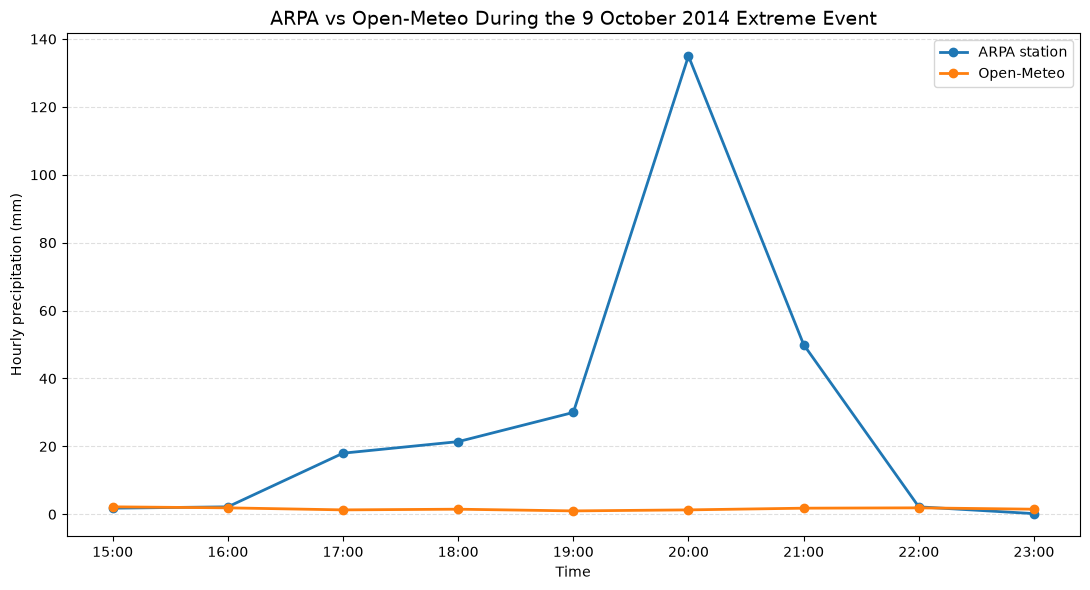

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    comparison_event["start_time"],
    comparison_event["arpal_precipitation_mm"],
    marker="o",
    linewidth=2,
    label="ARPA station"
)

ax.plot(
    comparison_event["start_time"],
    comparison_event["openmeteo_precipitation_mm"],
    marker="o",
    linewidth=2,
    label="Open-Meteo"
)

ax.set_title(
    "ARPA vs Open-Meteo During the 9 October 2014 Extreme Event",
    fontsize=14
)

ax.set_xlabel("Time")
ax.set_ylabel("Hourly precipitation (mm)")

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%H:%M")
)

ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [15]:
import geopandas as gpd

comuni = gpd.read_file("../data/raw/Comuni.shp")

print("Shape:", comuni.shape)
print("\nColumns:")
print(comuni.columns.tolist())

print("\nCRS:")
print(comuni.crs)

print("\nFirst rows:")
display(comuni.head())

Shape: (706, 21)

Columns:
['ogr_fid', 'cod_prov', 'cod_com', 'codice_com', 'cod_catast', 'cap_princi', 'nome_provi', 'nome_comun', 'popolazion', 'popolazi_1', 'popolazi_2', 'area_ha_gi', 'area_kmq_g', 'estremi_le', 'vigente', 'data_inizi', 'data_fine_', 'id', 'sup_ha_ist', 'sup_kmq_is', 'geometry']

CRS:
EPSG:7791

First rows:


,ogr_fid,cod_prov,cod_com,codice_com,cod_catast,cap_princi,nome_provi,nome_comun,popolazion,popolazi_1,...,area_ha_gi,area_kmq_g,estremi_le,vigente,data_inizi,data_fine_,id,sup_ha_ist,sup_kmq_is,geometry
0,2,011,011,011011,C240,19030,LA SPEZIA,CASTELNUOVO MAGRA,7896.0,7935.0,...,1493.43,14.93,NaN,SI,20000101,99999999,89,1501.72,15.0172,"POLYGON Z ((580664.279 4879529.944 0, 580629.8..."
1,3,011,026,011026,I363,19037,LA SPEZIA,SANTO STEFANO DI MAGRA,7881.0,5983.0,...,1393.79,13.94,NaN,SI,20000101,99999999,90,1385.26,13.8526,"POLYGON Z ((574570.597 4886542.578 0, 574553.3..."
2,4,011,002,011002,A373,19021,LA SPEZIA,ARCOLA,9553.0,9914.0,...,1639.51,16.40,NaN,SI,20000101,99999999,91,1653.81,16.5381,"POLYGON Z ((575667.808 4881833.901 0, 575663.3..."
3,5,011,031,011031,L819,19020,LA SPEZIA,VEZZANO LIGURE,7539.0,7424.0,...,1842.66,18.43,NaN,SI,20000101,99999999,92,1837.16,18.3716,"POLYGON Z ((574625.095 4885710.838 0, 574128.7..."
4,6,011,004,011004,A932,19020,LA SPEZIA,BOLANO,7068.0,7391.0,...,1467.38,14.67,NaN,SI,20000101,99999999,93,1456.64,14.5664,"POLYGON Z ((569143.612 4892331.147 0, 569130.8..."


In [16]:
genova = comuni[
    comuni["nome_comun"].str.upper().str.contains("GENOVA", na=False)
]

display(genova[["nome_provi", "nome_comun", "geometry"]])

,nome_provi,nome_comun,geometry
545,GENOVA,GENOVA,"POLYGON Z ((479140.321 4918955.118 0, 479139.6..."
546,GENOVA,GENOVA,"POLYGON Z ((484807.64 4918893.264 0, 484800.57..."
547,GENOVA,GENOVA,"POLYGON Z ((483867.955 4918891.372 0, 483850.7..."
548,GENOVA,GENOVA,"POLYGON Z ((484781.36 4918884.594 0, 484781.64..."
549,GENOVA,GENOVA,"POLYGON Z ((484759.87 4918876.404 0, 484755.62..."
...,...,...,...
611,GENOVA,GENOVA,"POLYGON Z ((504235.251 4913976.136 0, 504231.2..."
612,GENOVA,GENOVA,"POLYGON Z ((504286.3 4913954.076 0, 504284.55 ..."
613,GENOVA,GENOVA,"POLYGON Z ((504260.76 4913917.316 0, 504255.59..."
614,GENOVA,GENOVA,"POLYGON Z ((504312.75 4913916.906 0, 504316.07..."


In [17]:
# Merge fragmented polygons belonging to the same municipality
comuni_dissolved = comuni.dissolve(
    by="nome_comun",
    as_index=False
)

print("Municipalities after dissolve:", len(comuni_dissolved))

display(
    comuni_dissolved[
        comuni_dissolved["nome_comun"].str.upper() == "GENOVA"
    ][["nome_comun", "geometry"]]
)

Municipalities after dissolve: 234


,nome_comun,geometry
97,GENOVA,"MULTIPOLYGON Z (((476800.894 4917880.638 0, 47..."


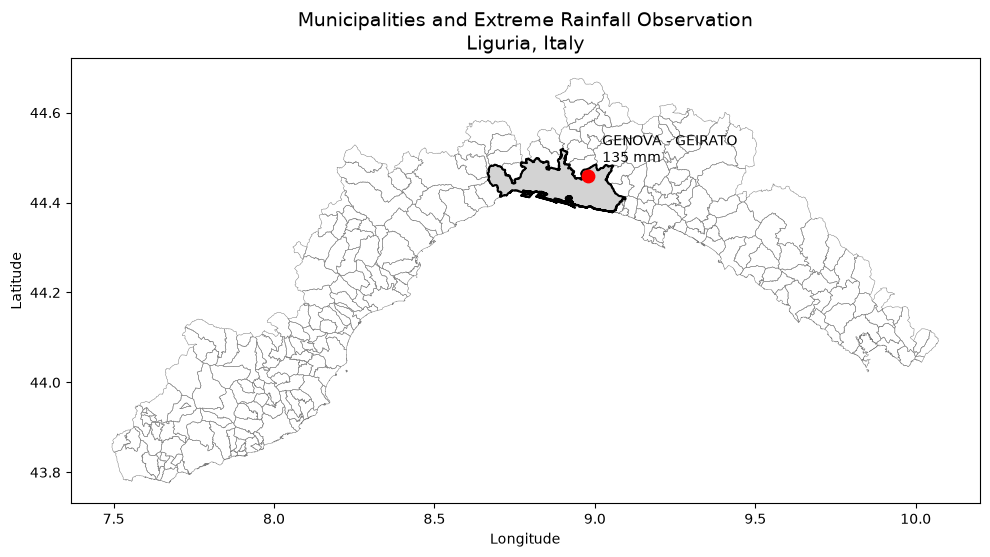

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Reproject municipalities to WGS84
comuni_wgs84 = comuni_dissolved.to_crs("EPSG:4326")

# Genova municipality
genova_wgs84 = comuni_wgs84[
    comuni_wgs84["nome_comun"].str.upper() == "GENOVA"
]

# ARPA Geirato station
station_gdf = gpd.GeoDataFrame(
    {
        "station": ["GENOVA - GEIRATO"],
        "rainfall_mm": [135.0]
    },
    geometry=[Point(8.97959, 44.45966)],
    crs="EPSG:4326"
)

# Create map
fig, ax = plt.subplots(figsize=(10, 9))

# All municipalities
comuni_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.35
)

# Highlight Genova
genova_wgs84.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

# Geirato station
station_gdf.plot(
    ax=ax,
    color="red",
    markersize=80,
    zorder=5
)

# Station label
x = station_gdf.geometry.x.iloc[0]
y = station_gdf.geometry.y.iloc[0]

ax.annotate(
    "GENOVA - GEIRATO\n135 mm",
    xy=(x, y),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=10
)

ax.set_title(
    "Municipalities and Extreme Rainfall Observation\nLiguria, Italy",
    fontsize=14
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [19]:
# Find the municipality containing the Geirato station

station_municipality = gpd.sjoin(
    station_gdf,
    comuni_wgs84[["nome_comun", "geometry"]],
    how="left",
    predicate="within"
)

display(
    station_municipality[
        ["station", "rainfall_mm", "nome_comun"]
    ]
)

,station,rainfall_mm,nome_comun
0,GENOVA - GEIRATO,135.0,GENOVA


In [20]:
# Create a spatial hazard summary for the Geirato station

hazard_summary = station_municipality[
    ["station", "rainfall_mm", "nome_comun", "geometry"]
].copy()

hazard_summary["longitude"] = hazard_summary.geometry.x
hazard_summary["latitude"] = hazard_summary.geometry.y

hazard_summary = hazard_summary.drop(columns="geometry")

hazard_summary["event_date"] = "2014-10-09"
hazard_summary["event_time"] = "20:00"

display(hazard_summary)

,station,rainfall_mm,nome_comun,longitude,latitude,event_date,event_time
0,GENOVA - GEIRATO,135.0,GENOVA,8.97959,44.45966,2014-10-09,20:00


In [21]:
# Classify the observed extreme rainfall event

def classify_rainfall(rainfall):
    if rainfall >= 100:
        return "Exceptional"
    elif rainfall >= 50:
        return "Very Heavy"
    elif rainfall >= 25:
        return "Heavy"
    else:
        return "Moderate"

hazard_summary["hazard_class"] = (
    hazard_summary["rainfall_mm"]
    .apply(classify_rainfall)
)

display(hazard_summary)

,station,rainfall_mm,nome_comun,longitude,latitude,event_date,event_time,hazard_class
0,GENOVA - GEIRATO,135.0,GENOVA,8.97959,44.45966,2014-10-09,20:00,Exceptional


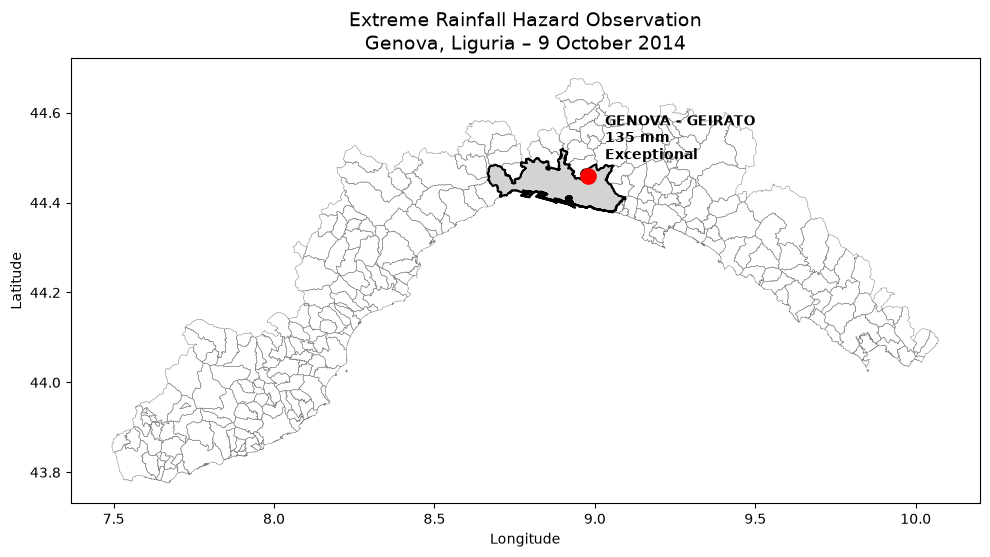

In [22]:
# Hazard map of the extreme rainfall observation

fig, ax = plt.subplots(figsize=(10, 9))

# Municipal boundaries
comuni_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="gray",
    linewidth=0.35
)

# Genova municipality
genova_wgs84.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=1.5
)

# Extreme rainfall observation
station_gdf.plot(
    ax=ax,
    color="red",
    markersize=120,
    zorder=5
)

# Label
ax.annotate(
    "GENOVA - GEIRATO\n135 mm\nExceptional",
    xy=(x, y),
    xytext=(12, 12),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Extreme Rainfall Hazard Observation\nGenova, Liguria – 9 October 2014",
    fontsize=14
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [23]:
# Reproject to a metric CRS for distance calculations
comuni_metric = comuni_dissolved.to_crs("EPSG:7791")
station_metric = station_gdf.to_crs("EPSG:7791")

print("CRS:", comuni_metric.crs)

CRS: EPSG:7791


In [24]:
# Create a 10 km buffer around the Geirato rainfall station

station_buffer = station_metric.copy()
station_buffer["geometry"] = station_buffer.geometry.buffer(10000)

# Find municipalities that intersect the 10 km buffer
nearby_municipalities = comuni_metric[
    comuni_metric.geometry.intersects(
        station_buffer.geometry.iloc[0]
    )
].copy()

print("Municipalities within/intersecting 10 km:", len(nearby_municipalities))

display(
    nearby_municipalities[
        ["nome_provi", "nome_comun"]
    ].sort_values("nome_comun")
)

Municipalities within/intersecting 10 km: 13


,nome_provi,nome_comun
20,GENOVA,BARGAGLI
43,GENOVA,CAMPOMORONE
52,GENOVA,CASELLA
61,GENOVA,CERANESI
80,GENOVA,DAVAGNA
97,GENOVA,GENOVA
113,GENOVA,LUMARZO
123,GENOVA,MIGNANEGO
133,GENOVA,MONTOGGIO
186,GENOVA,SANT'OLCESE


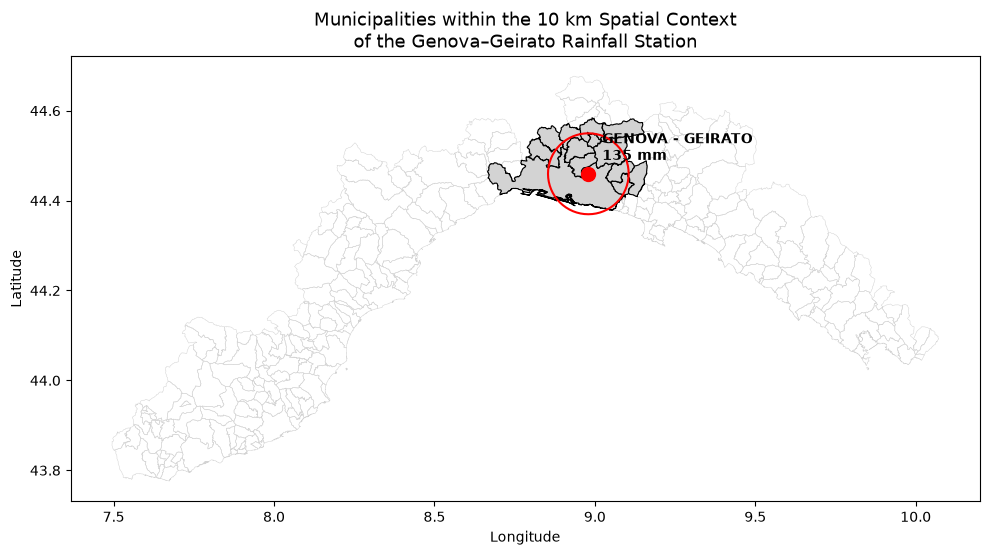

In [25]:
# Map of municipalities intersecting the 10 km station buffer

fig, ax = plt.subplots(figsize=(10, 9))

# All Liguria municipalities
comuni_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="lightgray",
    linewidth=0.35
)

# Nearby municipalities
nearby_wgs84 = nearby_municipalities.to_crs("EPSG:4326")

nearby_wgs84.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black",
    linewidth=0.8
)

# 10 km buffer
buffer_wgs84 = station_buffer.to_crs("EPSG:4326")

buffer_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=1.5
)

# Geirato station
station_gdf.plot(
    ax=ax,
    color="red",
    markersize=100,
    zorder=5
)

# Station label
ax.annotate(
    "GENOVA - GEIRATO\n135 mm",
    xy=(x, y),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Municipalities within the 10 km Spatial Context\n"
    "of the Genova–Geirato Rainfall Station",
    fontsize=13
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [27]:
# Final Hazard Summary - self-contained

import pandas as pd

# Load ARPA processed data
arpa_raw = pd.read_csv(
    "../data/raw/40777765150469.csv",
    encoding="latin1",
    skiprows=5,
    header=0,
    on_bad_lines="skip"
)

arpa_raw = arpa_raw.rename(columns={
    "Inizio rilevazione": "start_time",
    "Fine rilevazione": "end_time",
    "Valore": "value",
    "Dataset": "dataset",
    "Valido": "valid"
})

arpa_raw["start_time"] = pd.to_datetime(
    arpa_raw["start_time"],
    format="%d/%m/%Y %H:%M",
    errors="coerce"
)

arpa_raw["value"] = pd.to_numeric(
    arpa_raw["value"],
    errors="coerce"
)

arpa_raw = arpa_raw.dropna(
    subset=["start_time", "value"]
).copy()

# Load ARPA vs Open-Meteo comparison
precipitation = pd.read_csv(
    "../data/processed/precipitation_comparison.csv"
)

# Main rainfall statistics
max_rainfall = arpa_raw["value"].max()
mean_rainfall = arpa_raw["value"].mean()
median_rainfall = arpa_raw["value"].median()
number_of_observations = len(arpa_raw)

# Comparison metrics
mae = precipitation["absolute_error_mm"].mean()
max_error = precipitation["absolute_error_mm"].max()

# Hazard classification
def classify_rainfall(rainfall):
    if rainfall >= 100:
        return "Exceptional"
    elif rainfall >= 50:
        return "Very Heavy"
    elif rainfall >= 25:
        return "Heavy"
    else:
        return "Moderate"

hazard_class = classify_rainfall(max_rainfall)

# Number of nearby municipalities
nearby_count = len(nearby_municipalities)

# Final summary table
final_summary = pd.DataFrame({
    "indicator": [
        "Rainfall station",
        "Municipality",
        "Maximum observed rainfall (mm)",
        "Mean rainfall (mm)",
        "Median rainfall (mm)",
        "Number of observations",
        "Hazard class",
        "Municipalities within 10 km",
        "ARPA vs Open-Meteo MAE (mm)",
        "Maximum absolute difference (mm)"
    ],
    "value": [
        "GENOVA - GEIRATO",
        "GENOVA",
        round(max_rainfall, 2),
        round(mean_rainfall, 2),
        round(median_rainfall, 2),
        number_of_observations,
        hazard_class,
        nearby_count,
        round(mae, 2),
        round(max_error, 2)
    ]
})

display(final_summary)

,indicator,value
0,Rainfall station,GENOVA - GEIRATO
1,Municipality,GENOVA
2,Maximum observed rainfall (mm),135.0
3,Mean rainfall (mm),6.46
4,Median rainfall (mm),0.0
5,Number of observations,107
6,Hazard class,Exceptional
7,Municipalities within 10 km,13
8,ARPA vs Open-Meteo MAE (mm),6.64
9,Maximum absolute difference (mm),133.7


In [28]:
# Save the final hazard summary

final_summary.to_csv(
    "../data/processed/final_hazard_summary.csv",
    index=False
)

print("Final hazard summary saved successfully.")

Final hazard summary saved successfully.


In [30]:
# Load and prepare municipal boundaries

import geopandas as gpd
import matplotlib.pyplot as plt

# Load official municipal boundaries
municipalities = gpd.read_file(
    "../data/raw/Comuni.shp"
)

# Reproject to WGS84 for geographic visualization
municipalities_wgs84 = municipalities.to_crs("EPSG:4326")

print("Municipalities:", len(municipalities_wgs84))
print("CRS:", municipalities_wgs84.crs)

Municipalities: 706
CRS: EPSG:4326


In [2]:
# Recreate the station GeoDataFrame

from shapely.geometry import Point
import geopandas as gpd

station_lat = 44.45966
station_lon = 8.97959
station_elevation = 58

station_gdf = gpd.GeoDataFrame(
    {
        "station": ["GENOVA - GEIRATO"],
        "latitude": [station_lat],
        "longitude": [station_lon],
        "elevation_m": [station_elevation]
    },
    geometry=[Point(station_lon, station_lat)],
    crs="EPSG:4326"
)

station_wgs84 = station_gdf.to_crs("EPSG:4326")

print(station_wgs84)

            station  latitude  longitude  elevation_m  \
0  GENOVA - GEIRATO  44.45966    8.97959           58   

                   geometry  
0  POINT (8.97959 44.45966)  


In [4]:
# Load and prepare municipal boundaries

import geopandas as gpd

municipalities = gpd.read_file(
    "../data/raw/Comuni.shp"
)

municipalities_wgs84 = municipalities.to_crs("EPSG:4326")

print("Municipal spatial units:", len(municipalities_wgs84))
print("CRS:", municipalities_wgs84.crs)

Municipal spatial units: 706
CRS: EPSG:4326


In [5]:
# Create a 10 km buffer around the station

# Reproject to a metric CRS (UTM Zone 32N)
station_metric = station_wgs84.to_crs("EPSG:32632")
municipalities_metric = municipalities_wgs84.to_crs("EPSG:32632")

# Create a 10 km buffer
station_buffer_10km = station_metric.copy()
station_buffer_10km["geometry"] = station_metric.geometry.buffer(10000)

# Find municipal spatial units intersecting the buffer
municipalities_near_station = municipalities_metric[
    municipalities_metric.geometry.intersects(
        station_buffer_10km.geometry.iloc[0]
    )
].copy()

print(
    "Municipal spatial units within/intersecting 10 km:",
    len(municipalities_near_station)
)

Municipal spatial units within/intersecting 10 km: 26


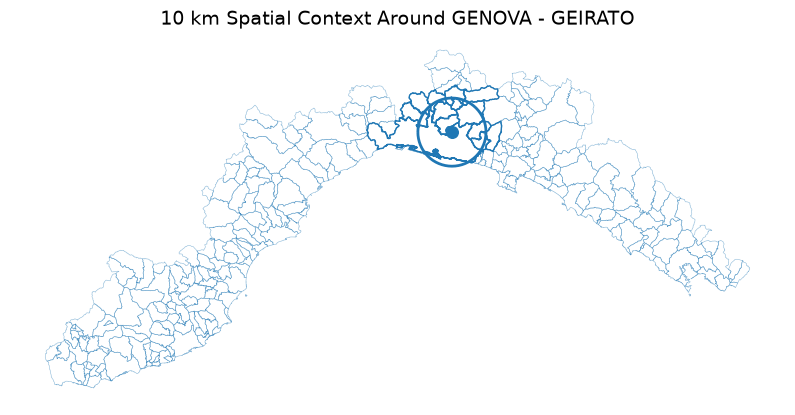

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Plot all municipalities as light boundaries
municipalities_metric.boundary.plot(
    ax=ax,
    linewidth=0.4,
    alpha=0.5
)

# Plot the 10 km buffer
station_buffer_10km.boundary.plot(
    ax=ax,
    linewidth=2
)

# Highlight spatial units intersecting the buffer
municipalities_near_station.boundary.plot(
    ax=ax,
    linewidth=1
)

# Plot the station
station_metric.plot(
    ax=ax,
    markersize=70,
    zorder=5
)

ax.set_title(
    "10 km Spatial Context Around GENOVA - GEIRATO",
    fontsize=14
)

ax.set_axis_off()

plt.show()

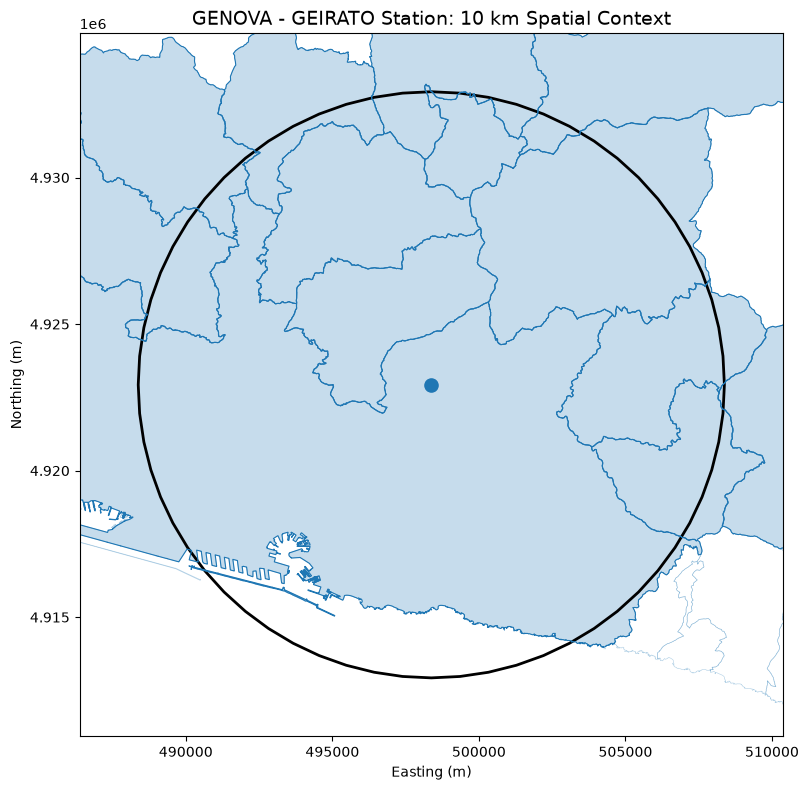

In [7]:
# Professional map of the 10 km station-based spatial context

fig, ax = plt.subplots(figsize=(10, 8))

# Plot municipal boundaries in the surrounding area
municipalities_metric.boundary.plot(
    ax=ax,
    linewidth=0.4,
    alpha=0.35
)

# Highlight municipalities intersecting the 10 km buffer
municipalities_near_station.plot(
    ax=ax,
    alpha=0.25
)

municipalities_near_station.boundary.plot(
    ax=ax,
    linewidth=0.8
)

# Plot the 10 km buffer
station_buffer_10km.plot(
    ax=ax,
    facecolor="none",
    linewidth=2
)

# Plot the station
station_metric.plot(
    ax=ax,
    markersize=90,
    zorder=5
)

# Zoom around the buffer
buffer_bounds = station_buffer_10km.total_bounds

margin = 2000  # 2 km margin around the buffer

ax.set_xlim(buffer_bounds[0] - margin, buffer_bounds[2] + margin)
ax.set_ylim(buffer_bounds[1] - margin, buffer_bounds[3] + margin)

ax.set_title(
    "GENOVA - GEIRATO Station: 10 km Spatial Context",
    fontsize=14
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

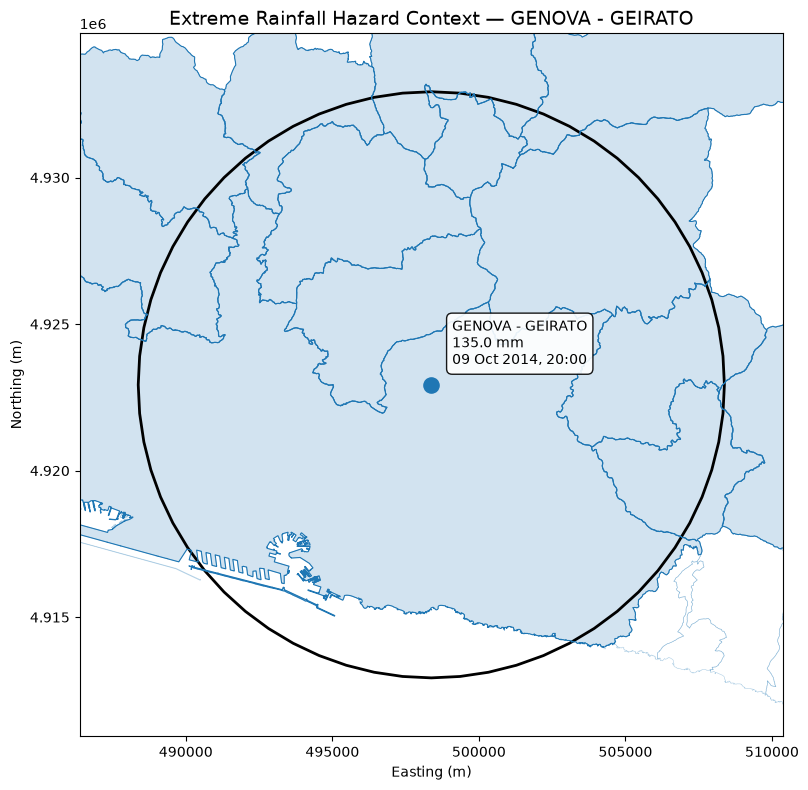

In [8]:
# Extreme rainfall hazard visualization

import matplotlib.pyplot as plt

# Extreme rainfall event recorded at GENOVA - GEIRATO
extreme_rainfall_mm = 135.0
event_date = "09 Oct 2014"
event_time = "20:00"

fig, ax = plt.subplots(figsize=(10, 8))

# Municipal boundaries
municipalities_metric.boundary.plot(
    ax=ax,
    linewidth=0.4,
    alpha=0.35
)

# Municipal spatial units intersecting the 10 km context
municipalities_near_station.plot(
    ax=ax,
    alpha=0.20
)

municipalities_near_station.boundary.plot(
    ax=ax,
    linewidth=0.8
)

# 10 km spatial context
station_buffer_10km.plot(
    ax=ax,
    facecolor="none",
    linewidth=2
)

# Station
station_metric.plot(
    ax=ax,
    markersize=120,
    zorder=5
)

# Station label
station_point = station_metric.geometry.iloc[0]

ax.annotate(
    f"GENOVA - GEIRATO\n{extreme_rainfall_mm:.1f} mm\n{event_date}, {event_time}",
    xy=(station_point.x, station_point.y),
    xytext=(15, 15),
    textcoords="offset points",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        edgecolor="black",
        alpha=0.9
    )
)

# Zoom around the station buffer
buffer_bounds = station_buffer_10km.total_bounds
margin = 2000

ax.set_xlim(buffer_bounds[0] - margin, buffer_bounds[2] + margin)
ax.set_ylim(buffer_bounds[1] - margin, buffer_bounds[3] + margin)

ax.set_title(
    "Extreme Rainfall Hazard Context — GENOVA - GEIRATO",
    fontsize=14
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

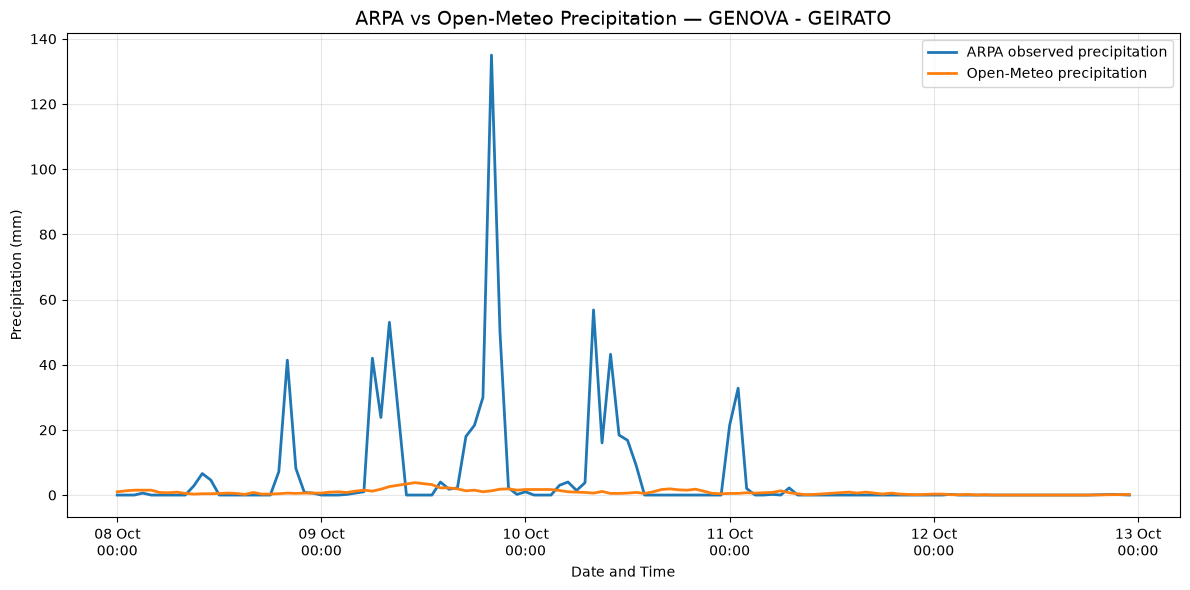

In [9]:
# ARPA vs Open-Meteo precipitation comparison

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the processed comparison dataset
comparison = pd.read_csv(
    "../data/processed/precipitation_comparison.csv"
)

# Convert time column to datetime
comparison["time"] = pd.to_datetime(comparison["time"])

# Create the time-series plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    comparison["time"],
    comparison["arpal_precipitation_mm"],
    label="ARPA observed precipitation",
    linewidth=2
)

ax.plot(
    comparison["time"],
    comparison["openmeteo_precipitation_mm"],
    label="Open-Meteo precipitation",
    linewidth=2
)

# Labels and title
ax.set_title(
    "ARPA vs Open-Meteo Precipitation — GENOVA - GEIRATO",
    fontsize=14
)

ax.set_xlabel("Date and Time")
ax.set_ylabel("Precipitation (mm)")

# Format the time axis
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b\n%H:%M")
)

# Grid and legend
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [10]:
# Quantitative comparison: ARPA vs Open-Meteo

# Calculate comparison metrics
mae = comparison["absolute_error_mm"].mean()
max_absolute_error = comparison["absolute_error_mm"].max()
mean_difference = comparison["difference_mm"].mean()

# Identify the record with the maximum absolute error
max_error_row = comparison.loc[
    comparison["absolute_error_mm"].idxmax()
]

# Calculate MAE excluding the largest discrepancy
comparison_without_max = comparison.drop(max_error_row.name)

mae_without_max = comparison_without_max["absolute_error_mm"].mean()

# Display results
print("ARPA vs Open-Meteo Comparison")
print("--------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.2f} mm")
print(f"Maximum Absolute Error: {max_absolute_error:.2f} mm")
print(f"Mean Difference (ARPA - Open-Meteo): {mean_difference:.2f} mm")
print(f"MAE excluding maximum discrepancy: {mae_without_max:.2f} mm")

print("\nLargest discrepancy:")
print(f"Time: {max_error_row['time']}")
print(f"ARPA: {max_error_row['arpal_precipitation_mm']:.1f} mm")
print(f"Open-Meteo: {max_error_row['openmeteo_precipitation_mm']:.1f} mm")
print(f"Absolute error: {max_error_row['absolute_error_mm']:.1f} mm")

ARPA vs Open-Meteo Comparison
--------------------------------
Mean Absolute Error (MAE): 6.64 mm
Maximum Absolute Error: 133.70 mm
Mean Difference (ARPA - Open-Meteo): 5.55 mm
MAE excluding maximum discrepancy: 5.44 mm

Largest discrepancy:
Time: 2014-10-09 20:00:00
ARPA: 135.0 mm
Open-Meteo: 1.3 mm
Absolute error: 133.7 mm


## Quantitative Comparison Results

The comparison between ARPA station observations and Open-Meteo precipitation estimates shows substantial differences during intense rainfall periods.

| Metric | Result |
|---|---:|
| Mean Absolute Error (MAE) | 6.64 mm |
| Maximum Absolute Error | 133.70 mm |
| Mean Difference (ARPA − Open-Meteo) | 5.55 mm |
| MAE excluding maximum discrepancy | 5.44 mm |

The largest discrepancy occurred on **9 October 2014 at 20:00**, when ARPA recorded **135.0 mm** of precipitation while Open-Meteo estimated **1.3 mm**, resulting in an absolute difference of **133.7 mm**.

### Interpretation

The results indicate that the gridded Open-Meteo dataset does not fully capture the highly localized precipitation peak observed at the GENOVA - GEIRATO station.

This highlights the importance of ground-based observations when assessing localized extreme rainfall and flash flood hazards. The comparison should be interpreted as an evaluation of differences between station observations and gridded precipitation estimates, rather than as a determination that one dataset is universally more accurate.

In [11]:
# Event-level comparison: 9–10 October 2014

# Make sure time is datetime
comparison["time"] = pd.to_datetime(comparison["time"])

# Select the main event period
event_data = comparison[
    (comparison["time"] >= "2014-10-09 00:00:00") &
    (comparison["time"] <= "2014-10-10 23:59:59")
].copy()

# Calculate event totals
arpa_total = event_data["arpal_precipitation_mm"].sum()
openmeteo_total = event_data["openmeteo_precipitation_mm"].sum()

total_difference = arpa_total - openmeteo_total

# Calculate event-level MAE
event_mae = event_data["absolute_error_mm"].mean()

# Maximum hourly precipitation during the event
arpa_max = event_data["arpal_precipitation_mm"].max()
openmeteo_max = event_data["openmeteo_precipitation_mm"].max()

# Print results
print("9–10 October 2014 Event Comparison")
print("-----------------------------------")
print(f"ARPA total precipitation: {arpa_total:.1f} mm")
print(f"Open-Meteo total precipitation: {openmeteo_total:.1f} mm")
print(f"Total difference: {total_difference:.1f} mm")
print(f"Event MAE: {event_mae:.2f} mm")
print(f"ARPA maximum hourly precipitation: {arpa_max:.1f} mm")
print(f"Open-Meteo maximum hourly precipitation: {openmeteo_max:.1f} mm")

9–10 October 2014 Event Comparison
-----------------------------------
ARPA total precipitation: 559.0 mm
Open-Meteo total precipitation: 68.0 mm
Total difference: 491.0 mm
Event MAE: 12.26 mm
ARPA maximum hourly precipitation: 135.0 mm
Open-Meteo maximum hourly precipitation: 3.8 mm


## Event-Level Comparison: 9–10 October 2014

The event-level comparison shows that the difference between station-based observations and gridded precipitation estimates is not limited to a single extreme hourly value.

During 9–10 October 2014, the GENOVA - GEIRATO station recorded a total precipitation of **559.0 mm**, while Open-Meteo estimated **68.0 mm** for the same period. This corresponds to a total difference of **491.0 mm**.

The event-level Mean Absolute Error (MAE) was **12.26 mm**, while the maximum hourly precipitation was **135.0 mm** in the ARPA observations compared with **3.8 mm** in the Open-Meteo dataset.

### Interpretation

The persistence of large differences at the event scale indicates that the discrepancy is not caused solely by the single maximum rainfall peak. The results suggest that the gridded precipitation dataset does not fully represent the highly localized and intense rainfall observed at the GENOVA - GEIRATO station during this event.

This finding is particularly relevant for flash flood analysis, where localized precipitation intensity and accumulation can strongly influence hazard conditions.

The comparison should not be interpreted as evidence that one dataset is universally more accurate than the other. Instead, it demonstrates the importance of considering data source, spatial resolution, and local observations when analysing extreme precipitation events.

## Hazard Interpretation and Decision-Support Implications

The event-level comparison indicates a substantial difference between the station-based observations and the gridded precipitation estimates during the 9–10 October 2014 event.

The GENOVA - GEIRATO station recorded **559.0 mm** of precipitation, while Open-Meteo estimated **68.0 mm** over the same period. Therefore, the Open-Meteo estimate represents only approximately **12%** of the precipitation recorded by the station during this event.

From a flash flood risk perspective, this difference is important because both rainfall intensity and accumulated precipitation can strongly influence rapid runoff generation and flooding, particularly in highly urbanized and topographically constrained environments.

The results suggest that relying only on gridded precipitation estimates may lead to a substantial under-representation of the severity of a highly localized rainfall event at the station location.

### Decision-Support Insight

For operational or post-event hazard assessment, ground-based observations can provide critical local information that may not be fully represented by gridded precipitation products.

A robust hazard assessment should therefore consider:

- **Local rain-gauge observations** for detecting and quantifying extreme rainfall
- **Gridded precipitation products** for broader spatial coverage
- **Spatial context** to identify potentially affected areas
- **Temporal rainfall intensity and accumulation** when assessing flash flood potential

The analysis demonstrates that combining complementary data sources can provide a more informative basis for understanding localized extreme precipitation and its potential implications for flash flood risk.

### Important Limitation

The rainfall analysis is based on a single station, GENOVA - GEIRATO. Therefore, these results should not be interpreted as a spatial rainfall distribution across Liguria.

The spatial analysis provides a **station-based hazard context**, while the comparison between ARPA and Open-Meteo provides an assessment of differences between local observations and gridded precipitation estimates.

In [12]:
# Temporal concentration of the 9–10 October 2014 rainfall event

event_data = comparison[
    (comparison["time"] >= "2014-10-09 00:00:00") &
    (comparison["time"] <= "2014-10-10 23:59:59")
].copy()

event_data = event_data.sort_values("time")

# Calculate rolling rainfall accumulation
event_data["rain_3h"] = event_data["arpal_precipitation_mm"].rolling(3).sum()
event_data["rain_6h"] = event_data["arpal_precipitation_mm"].rolling(6).sum()
event_data["rain_12h"] = event_data["arpal_precipitation_mm"].rolling(12).sum()
event_data["rain_24h"] = event_data["arpal_precipitation_mm"].rolling(24).sum()

# Find maximum accumulations
max_3h = event_data["rain_3h"].max()
max_6h = event_data["rain_6h"].max()
max_12h = event_data["rain_12h"].max()
max_24h = event_data["rain_24h"].max()

# Percentage of the event total
event_total = event_data["arpal_precipitation_mm"].sum()

print("Temporal Concentration of Rainfall")
print("----------------------------------")
print(f"Event total rainfall: {event_total:.1f} mm")
print(f"Maximum 3-hour accumulation: {max_3h:.1f} mm")
print(f"Maximum 6-hour accumulation: {max_6h:.1f} mm")
print(f"Maximum 12-hour accumulation: {max_12h:.1f} mm")
print(f"Maximum 24-hour accumulation: {max_24h:.1f} mm")

print("\nMaximum accumulation as percentage of event total")
print("-----------------------------------------------")
print(f"3-hour:  {(max_3h / event_total) * 100:.1f}%")
print(f"6-hour:  {(max_6h / event_total) * 100:.1f}%")
print(f"12-hour: {(max_12h / event_total) * 100:.1f}%")
print(f"24-hour: {(max_24h / event_total) * 100:.1f}%")

Temporal Concentration of Rainfall
----------------------------------
Event total rainfall: 559.0 mm
Maximum 3-hour accumulation: 215.0 mm
Maximum 6-hour accumulation: 256.6 mm
Maximum 12-hour accumulation: 265.8 mm
Maximum 24-hour accumulation: 438.4 mm

Maximum accumulation as percentage of event total
-----------------------------------------------
3-hour:  38.5%
6-hour:  45.9%
12-hour: 47.5%
24-hour: 78.4%


In [13]:
# Identify the timing of maximum rainfall accumulation windows

windows = {
    "3-hour": "rain_3h",
    "6-hour": "rain_6h",
    "12-hour": "rain_12h",
    "24-hour": "rain_24h"
}

print("Peak Rainfall Accumulation Windows")
print("----------------------------------")

for label, column in windows.items():
    idx = event_data[column].idxmax()
    end_time = event_data.loc[idx, "time"]
    
    hours = int(label.split("-")[0])
    start_time = end_time - pd.Timedelta(hours=hours - 1)
    
    rainfall = event_data.loc[idx, column]
    
    print(
        f"{label}: {rainfall:.1f} mm | "
        f"{start_time} → {end_time}"
    )

Peak Rainfall Accumulation Windows
----------------------------------
3-hour: 215.0 mm | 2014-10-09 19:00:00 → 2014-10-09 21:00:00
6-hour: 256.6 mm | 2014-10-09 16:00:00 → 2014-10-09 21:00:00
12-hour: 265.8 mm | 2014-10-09 13:00:00 → 2014-10-10 00:00:00
24-hour: 438.4 mm | 2014-10-09 14:00:00 → 2014-10-10 13:00:00


## Temporal Hazard Insight

The temporal analysis shows that the 9–10 October 2014 rainfall event was strongly concentrated in time rather than being uniformly distributed across the two-day period.

The maximum 3-hour accumulation reached **215.0 mm** between **19:00 and 21:00 on 9 October**, representing **38.5% of the total event rainfall**.

The maximum 6-hour accumulation reached **256.6 mm**, while the maximum 24-hour accumulation reached **438.4 mm**, corresponding to **45.9%** and **78.4%** of the total event rainfall, respectively.

### Interpretation

The concentration of a large proportion of the event rainfall within short time windows is particularly relevant to flash flood hazard assessment. High rainfall accumulation over short periods can contribute to rapid runoff generation and may increase the potential for rapid flooding, especially in urban and topographically constrained environments.

The results therefore indicate that the severity of the event cannot be adequately represented by its total rainfall alone. **Rainfall intensity and temporal concentration are important components of flash flood hazard assessment.**

The identified peak windows provide a temporal basis for linking rainfall conditions with potential flood response and emergency management considerations.

In [14]:
# Final Hazard Summary

final_hazard_summary = pd.DataFrame({
    "Indicator": [
        "Event total rainfall (ARPA)",
        "Event total rainfall (Open-Meteo)",
        "Event rainfall difference",
        "Open-Meteo / ARPA rainfall ratio",
        "Maximum hourly rainfall (ARPA)",
        "Maximum hourly rainfall (Open-Meteo)",
        "Maximum 3-hour accumulation (ARPA)",
        "Maximum 6-hour accumulation (ARPA)",
        "Maximum 12-hour accumulation (ARPA)",
        "Maximum 24-hour accumulation (ARPA)"
    ],
    "Value": [
        arpa_total,
        openmeteo_total,
        total_difference,
        (openmeteo_total / arpa_total) * 100,
        arpa_max,
        openmeteo_max,
        max_3h,
        max_6h,
        max_12h,
        max_24h
    ],
    "Unit": [
        "mm",
        "mm",
        "mm",
        "%",
        "mm",
        "mm",
        "mm",
        "mm",
        "mm",
        "mm"
    ]
})

# Round values for presentation
final_hazard_summary["Value"] = final_hazard_summary["Value"].round(2)

# Display summary
display(final_hazard_summary)

# Save processed output
final_hazard_summary.to_csv(
    "../data/processed/final_hazard_summary.csv",
    index=False
)

print("\nFinal hazard summary saved successfully.")

,Indicator,Value,Unit
0,Event total rainfall (ARPA),559.00,mm
1,Event total rainfall (Open-Meteo),68.00,mm
2,Event rainfall difference,491.00,mm
3,Open-Meteo / ARPA rainfall ratio,12.16,%
4,Maximum hourly rainfall (ARPA),135.00,mm
5,Maximum hourly rainfall (Open-Meteo),3.80,mm
6,Maximum 3-hour accumulation (ARPA),215.00,mm
7,Maximum 6-hour accumulation (ARPA),256.60,mm
8,Maximum 12-hour accumulation (ARPA),265.80,mm
9,Maximum 24-hour accumulation (ARPA),438.40,mm



Final hazard summary saved successfully.


In [15]:
# Check hourly continuity of the event data

event_times = event_data["time"].sort_values()

time_differences = event_times.diff().dropna()

print("Time interval check")
print("------------------")
print(time_differences.value_counts().head(10))

print("\nNumber of non-hourly intervals:")
print((time_differences != pd.Timedelta(hours=1)).sum())

print("\nLargest time gap:")
print(time_differences.max())

Time interval check
------------------
time
0 days 01:00:00    43
0 days 02:00:00     2
Name: count, dtype: int64

Number of non-hourly intervals:
2

Largest time gap:
0 days 02:00:00


In [16]:
# Identify the two non-hourly intervals

gap_mask = time_differences != pd.Timedelta(hours=1)

print("Non-hourly intervals")
print("--------------------")

for idx in time_differences[gap_mask].index:
    current_time = event_times.loc[idx]
    previous_time = event_times.loc[idx - 1]
    
    print(f"Previous: {previous_time}")
    print(f"Current:  {current_time}")
    print(f"Gap:     {current_time - previous_time}")
    print()

Non-hourly intervals
--------------------
Previous: 2014-10-09 08:00:00
Current:  2014-10-09 10:00:00
Gap:     0 days 02:00:00

Previous: 2014-10-10 20:00:00
Current:  2014-10-10 22:00:00
Gap:     0 days 02:00:00



In [17]:
# Recalculate rainfall accumulations using actual time windows

event_data_time = event_data.copy()
event_data_time = event_data_time.sort_values("time")
event_data_time = event_data_time.set_index("time")

# Time-based rolling accumulations
event_data_time["rain_3h"] = (
    event_data_time["arpal_precipitation_mm"]
    .rolling("3h")
    .sum()
)

event_data_time["rain_6h"] = (
    event_data_time["arpal_precipitation_mm"]
    .rolling("6h")
    .sum()
)

event_data_time["rain_12h"] = (
    event_data_time["arpal_precipitation_mm"]
    .rolling("12h")
    .sum()
)

event_data_time["rain_24h"] = (
    event_data_time["arpal_precipitation_mm"]
    .rolling("24h")
    .sum()
)

# Maximum accumulations
max_3h = event_data_time["rain_3h"].max()
max_6h = event_data_time["rain_6h"].max()
max_12h = event_data_time["rain_12h"].max()
max_24h = event_data_time["rain_24h"].max()

event_total = event_data_time["arpal_precipitation_mm"].sum()

print("Time-Based Rainfall Accumulation")
print("--------------------------------")
print(f"Event total rainfall: {event_total:.1f} mm")
print(f"Maximum 3-hour accumulation: {max_3h:.1f} mm")
print(f"Maximum 6-hour accumulation: {max_6h:.1f} mm")
print(f"Maximum 12-hour accumulation: {max_12h:.1f} mm")
print(f"Maximum 24-hour accumulation: {max_24h:.1f} mm")

print("\nAs percentage of event total")
print("----------------------------")
print(f"3-hour:  {(max_3h / event_total) * 100:.1f}%")
print(f"6-hour:  {(max_6h / event_total) * 100:.1f}%")
print(f"12-hour: {(max_12h / event_total) * 100:.1f}%")
print(f"24-hour: {(max_24h / event_total) * 100:.1f}%")

Time-Based Rainfall Accumulation
--------------------------------
Event total rainfall: 559.0 mm
Maximum 3-hour accumulation: 215.0 mm
Maximum 6-hour accumulation: 256.6 mm
Maximum 12-hour accumulation: 265.8 mm
Maximum 24-hour accumulation: 438.4 mm

As percentage of event total
----------------------------
3-hour:  38.5%
6-hour:  45.9%
12-hour: 47.5%
24-hour: 78.4%


In [18]:
# Update final hazard summary with validated time-based accumulations

final_hazard_summary = pd.DataFrame({
    "Indicator": [
        "Event total rainfall (ARPA)",
        "Event total rainfall (Open-Meteo)",
        "Event rainfall difference",
        "Open-Meteo / ARPA rainfall ratio",
        "Maximum hourly rainfall (ARPA)",
        "Maximum hourly rainfall (Open-Meteo)",
        "Maximum 3-hour accumulation (ARPA)",
        "Maximum 6-hour accumulation (ARPA)",
        "Maximum 12-hour accumulation (ARPA)",
        "Maximum 24-hour accumulation (ARPA)"
    ],
    "Value": [
        arpa_total,
        openmeteo_total,
        total_difference,
        (openmeteo_total / arpa_total) * 100,
        arpa_max,
        openmeteo_max,
        max_3h,
        max_6h,
        max_12h,
        max_24h
    ],
    "Unit": [
        "mm", "mm", "mm", "%", "mm",
        "mm", "mm", "mm", "mm", "mm"
    ]
})

final_hazard_summary["Value"] = final_hazard_summary["Value"].round(2)

display(final_hazard_summary)

final_hazard_summary.to_csv(
    "../data/processed/final_hazard_summary.csv",
    index=False
)

print("\nValidated final hazard summary saved successfully.")

,Indicator,Value,Unit
0,Event total rainfall (ARPA),559.00,mm
1,Event total rainfall (Open-Meteo),68.00,mm
2,Event rainfall difference,491.00,mm
3,Open-Meteo / ARPA rainfall ratio,12.16,%
4,Maximum hourly rainfall (ARPA),135.00,mm
5,Maximum hourly rainfall (Open-Meteo),3.80,mm
6,Maximum 3-hour accumulation (ARPA),215.00,mm
7,Maximum 6-hour accumulation (ARPA),256.60,mm
8,Maximum 12-hour accumulation (ARPA),265.80,mm
9,Maximum 24-hour accumulation (ARPA),438.40,mm



Validated final hazard summary saved successfully.


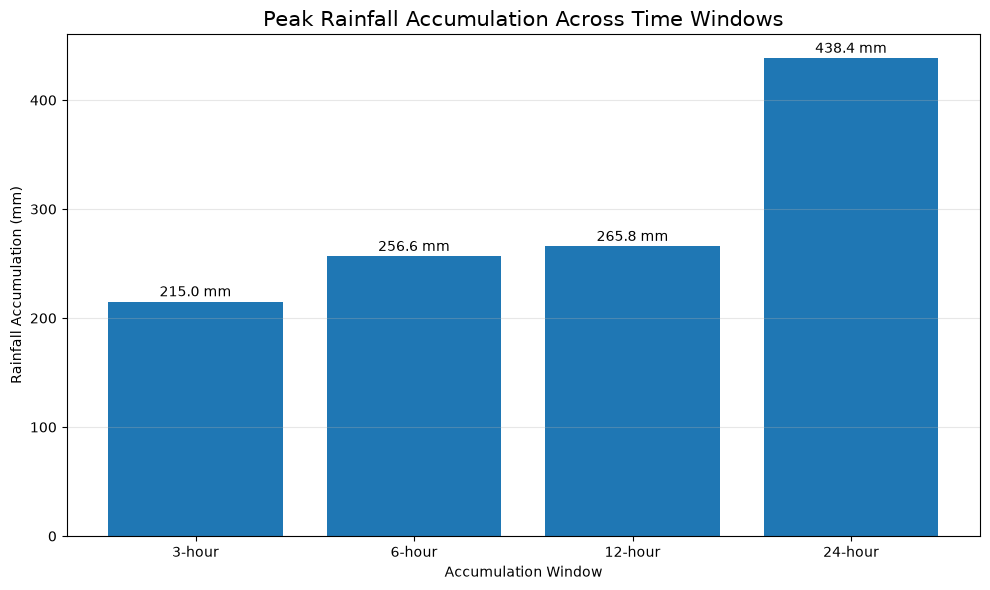

In [2]:
# Final temporal hazard visualization
# Recalculate accumulation values directly from the processed dataset

import pandas as pd
import matplotlib.pyplot as plt

# Load processed comparison data
comparison = pd.read_csv(
    "../data/processed/precipitation_comparison.csv"
)

comparison["time"] = pd.to_datetime(comparison["time"])
comparison = comparison.sort_values("time")

# Use ARPA station observations
rainfall = comparison.set_index("time")["arpal_precipitation_mm"]

# Time-based rolling accumulations
max_3h = rainfall.rolling("3h").sum().max()
max_6h = rainfall.rolling("6h").sum().max()
max_12h = rainfall.rolling("12h").sum().max()
max_24h = rainfall.rolling("24h").sum().max()

# Prepare visualization data
windows = ["3-hour", "6-hour", "12-hour", "24-hour"]
accumulations = [max_3h, max_6h, max_12h, max_24h]

# Create chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(windows, accumulations)

ax.set_title(
    "Peak Rainfall Accumulation Across Time Windows",
    fontsize=15
)
ax.set_xlabel("Accumulation Window")
ax.set_ylabel("Rainfall Accumulation (mm)")

ax.grid(axis="y", alpha=0.3)

# Add values above bars
for bar, value in zip(bars, accumulations):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        f"{value:.1f} mm",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [3]:
# Peak rainfall window summary

rolling_3h = rainfall.rolling("3h").sum()

peak_3h_time = rolling_3h.idxmax()
peak_3h_value = rolling_3h.max()

print("Peak 3-hour rainfall window")
print("----------------------------")
print(f"Start: {peak_3h_time - pd.Timedelta(hours=2)}")
print(f"End:   {peak_3h_time}")
print(f"Accumulation: {peak_3h_value:.1f} mm")

Peak 3-hour rainfall window
----------------------------
Start: 2014-10-09 19:00:00
End:   2014-10-09 21:00:00
Accumulation: 215.0 mm


In [5]:
# Peak 3-hour rainfall significance during the 9–10 October 2014 event

event_data = comparison[
    (comparison["time"] >= "2014-10-09 00:00:00") &
    (comparison["time"] <= "2014-10-10 23:59:59")
].copy()

event_rainfall = event_data.set_index("time")["arpal_precipitation_mm"]

rolling_3h_event = event_rainfall.rolling("3h").sum()

peak_3h = rolling_3h_event.max()
event_total = event_rainfall.sum()

peak_3h_percentage = (peak_3h / event_total) * 100

print("Peak 3-hour rainfall significance")
print("----------------------------------")
print(f"Event total rainfall: {event_total:.1f} mm")
print(f"Peak 3-hour accumulation: {peak_3h:.1f} mm")
print(f"Share of event total: {peak_3h_percentage:.1f}%")

Peak 3-hour rainfall significance
----------------------------------
Event total rainfall: 559.0 mm
Peak 3-hour accumulation: 215.0 mm
Share of event total: 38.5%


In [6]:
# Peak 6-hour rainfall significance

peak_6h = max_6h
peak_6h_percentage = (peak_6h / event_total) * 100

print("Peak 6-hour rainfall significance")
print("----------------------------------")
print(f"Event total rainfall: {event_total:.1f} mm")
print(f"Peak 6-hour accumulation: {peak_6h:.1f} mm")
print(f"Share of event total: {peak_6h_percentage:.1f}%")

Peak 6-hour rainfall significance
----------------------------------
Event total rainfall: 559.0 mm
Peak 6-hour accumulation: 256.6 mm
Share of event total: 45.9%


In [7]:
# Peak 12-hour rainfall significance

peak_12h = max_12h
peak_12h_percentage = (peak_12h / event_total) * 100

print("Peak 12-hour rainfall significance")
print("-----------------------------------")
print(f"Event total rainfall: {event_total:.1f} mm")
print(f"Peak 12-hour accumulation: {peak_12h:.1f} mm")
print(f"Share of event total: {peak_12h_percentage:.1f}%")

Peak 12-hour rainfall significance
-----------------------------------
Event total rainfall: 559.0 mm
Peak 12-hour accumulation: 265.8 mm
Share of event total: 47.5%


In [8]:
# Peak 24-hour rainfall significance

peak_24h = max_24h
peak_24h_percentage = (peak_24h / event_total) * 100

print("Peak 24-hour rainfall significance")
print("-----------------------------------")
print(f"Event total rainfall: {event_total:.1f} mm")
print(f"Peak 24-hour accumulation: {peak_24h:.1f} mm")
print(f"Share of event total: {peak_24h_percentage:.1f}%")

Peak 24-hour rainfall significance
-----------------------------------
Event total rainfall: 559.0 mm
Peak 24-hour accumulation: 438.4 mm
Share of event total: 78.4%


In [1]:
# Identify spatial units intersecting the 10 km buffer

# Reproject municipal boundaries to metric CRS
municipalities_metric = municipalities_wgs84.to_crs("EPSG:32632")

# Select spatial units intersecting the 10 km buffer
municipalities_near_station = municipalities_metric[
    municipalities_metric.geometry.intersects(
        station_buffer_10km.geometry.iloc[0]
    )
].copy()

print(
    "Municipal spatial units intersecting 10 km buffer:",
    len(municipalities_near_station)
)

NameError: name 'municipalities_wgs84' is not defined

In [2]:
import geopandas as gpd

# Load municipal boundaries
municipalities = gpd.read_file("../data/raw/Comuni.shp")

# Reproject to WGS84
municipalities_wgs84 = municipalities.to_crs("EPSG:4326")

# Reproject to metric CRS
municipalities_metric = municipalities_wgs84.to_crs("EPSG:32632")

# Create 10 km buffer around the station
station_metric = station_wgs84.to_crs("EPSG:32632")

station_buffer_10km = station_metric.copy()
station_buffer_10km["geometry"] = station_metric.geometry.buffer(10000)

# Select spatial units intersecting the buffer
municipalities_near_station = municipalities_metric[
    municipalities_metric.geometry.intersects(
        station_buffer_10km.geometry.iloc[0]
    )
].copy()

print(
    "Municipal spatial units intersecting 10 km buffer:",
    len(municipalities_near_station)
)

NameError: name 'station_wgs84' is not defined

In [3]:
import geopandas as gpd
from shapely.geometry import Point

# Station coordinates
station_lat = 44.45966
station_lon = 8.97959

# Create station GeoDataFrame
station_gdf = gpd.GeoDataFrame(
    {
        "station": ["GENOVA - GEIRATO"],
        "latitude": [station_lat],
        "longitude": [station_lon],
        "elevation_m": [58]
    },
    geometry=[Point(station_lon, station_lat)],
    crs="EPSG:4326"
)

# Reproject station to metric CRS
station_metric = station_gdf.to_crs("EPSG:32632")

# Create 10 km buffer
station_buffer_10km = station_metric.copy()
station_buffer_10km["geometry"] = station_metric.geometry.buffer(10000)

print("10 km buffer created successfully.")
print(station_buffer_10km)

10 km buffer created successfully.
            station  latitude  longitude  elevation_m  \
0  GENOVA - GEIRATO  44.45966    8.97959           58   

                                            geometry  
0  POLYGON ((508376.333 4922928.529, 508328.18 49...  


In [4]:
# Load municipal boundaries
municipalities = gpd.read_file("../data/raw/Comuni.shp")

# Reproject to metric CRS
municipalities_metric = municipalities.to_crs("EPSG:32632")

# Select spatial units intersecting the 10 km buffer
municipalities_near_station = municipalities_metric[
    municipalities_metric.geometry.intersects(
        station_buffer_10km.geometry.iloc[0]
    )
].copy()

print(
    "Municipal spatial units intersecting 10 km buffer:",
    len(municipalities_near_station)
)

Municipal spatial units intersecting 10 km buffer: 26


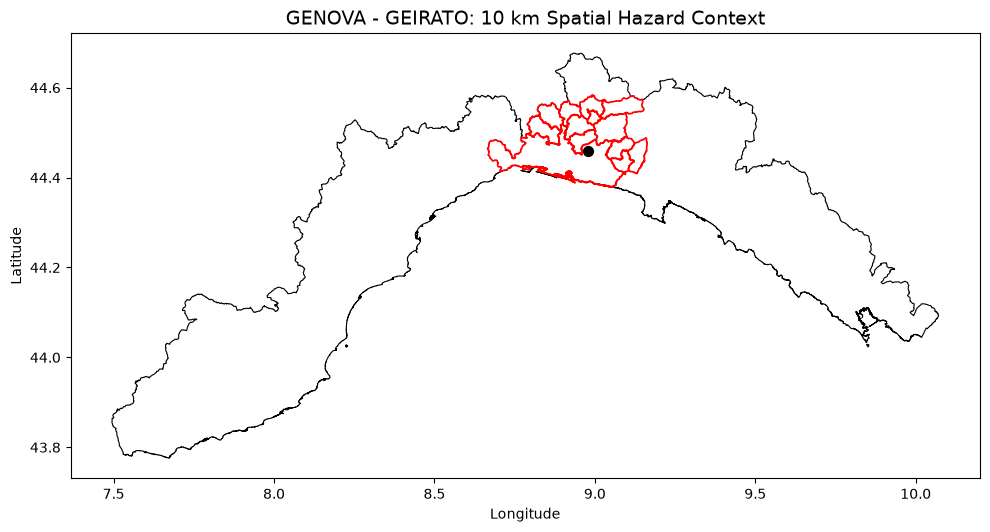

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Liguria boundary
liguria_wgs84 = gpd.read_file("../data/raw/Regione.shp").to_crs("EPSG:4326")

# Selected spatial units
municipalities_near_wgs84 = municipalities_near_station.to_crs("EPSG:4326")

# Plot region
liguria_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.8
)

# Plot selected spatial units
municipalities_near_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=1.2
)

# Plot station
station_gdf.plot(
    ax=ax,
    color="black",
    markersize=50,
    zorder=3
)

ax.set_title(
    "GENOVA - GEIRATO: 10 km Spatial Hazard Context",
    fontsize=14
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

In [6]:
print(municipalities.columns.tolist())

['ogr_fid', 'cod_prov', 'cod_com', 'codice_com', 'cod_catast', 'cap_princi', 'nome_provi', 'nome_comun', 'popolazion', 'popolazi_1', 'popolazi_2', 'area_ha_gi', 'area_kmq_g', 'estremi_le', 'vigente', 'data_inizi', 'data_fine_', 'id', 'sup_ha_ist', 'sup_kmq_is', 'geometry']


In [7]:
print(
    municipalities_near_station[
        ["cod_com", "codice_com", "nome_comun"]
    ]
    .drop_duplicates()
    .sort_values("nome_comun")
    .to_string(index=False)
)

cod_com codice_com   nome_comun
    003     010003     BARGAGLI
    009     010009  CAMPOMORONE
    012     010012      CASELLA
    014     010014     CERANESI
    021     010021      DAVAGNA
    025     010025       GENOVA
    031     010031      LUMARZO
    035     010035    MIGNANEGO
    039     010039    MONTOGGIO
    055     010055  SANT'OLCESE
    057     010057    SAVIGNONE
    058     010058 SERRA RICCO'
    065     010065  VALBREVENNA


In [8]:
# Dissolve fragmented spatial units into actual municipalities

municipalities_dissolved = (
    municipalities_metric
    .dissolve(
        by="cod_com",
        aggfunc={
            "codice_com": "first",
            "nome_comun": "first"
        }
    )
    .reset_index()
)

# Select municipalities intersecting the 10 km buffer
municipalities_near_station = municipalities_dissolved[
    municipalities_dissolved.geometry.intersects(
        station_buffer_10km.geometry.iloc[0]
    )
].copy()

print(
    "Municipalities intersecting 10 km buffer:",
    len(municipalities_near_station)
)

print(
    municipalities_near_station[
        ["cod_com", "nome_comun"]
    ]
    .sort_values("nome_comun")
    .to_string(index=False)
)

Municipalities intersecting 10 km buffer: 13
cod_com         nome_comun
    003 AQUILA DI ARROSCIA
    012         CARAVONICA
    009              CARRO
    014         CASTELLARO
    021           CIPRESSA
    035   MOLINI DI TRIORA
    039        OSPEDALETTI
    025  ROCCHETTA DI VARA
    055            SANREMO
    057            SEBORGA
    058            SOLDANO
    065        VENTIMIGLIA
    031     VEZZANO LIGURE


In [9]:
print(
    municipalities_near_station[
        ["codice_com", "nome_comun"]
    ]
    .drop_duplicates()
    .sort_values("nome_comun")
    .to_string(index=False)
)

codice_com         nome_comun
    008003 AQUILA DI ARROSCIA
    008012         CARAVONICA
    011009              CARRO
    008014         CASTELLARO
    008021           CIPRESSA
    008035   MOLINI DI TRIORA
    008039        OSPEDALETTI
    011025  ROCCHETTA DI VARA
    008055            SANREMO
    008057            SEBORGA
    008058            SOLDANO
    008065        VENTIMIGLIA
    011031     VEZZANO LIGURE


In [10]:
# Rebuild municipality-level spatial context using the full municipality code

import geopandas as gpd

# Load original municipal boundaries
municipalities = gpd.read_file("../data/raw/Comuni.shp")

# Reproject to metric CRS
municipalities_metric = municipalities.to_crs("EPSG:32632")

# Dissolve fragmented geometries using the full municipality code
municipalities_dissolved = (
    municipalities_metric
    .dissolve(
        by="codice_com",
        aggfunc={
            "cod_com": "first",
            "nome_comun": "first"
        }
    )
    .reset_index()
)

# Select actual municipalities intersecting the 10 km buffer
municipalities_near_station_final = municipalities_dissolved[
    municipalities_dissolved.geometry.intersects(
        station_buffer_10km.geometry.iloc[0]
    )
].copy()

print(
    "Actual municipalities intersecting 10 km buffer:",
    len(municipalities_near_station_final)
)

print(
    municipalities_near_station_final[
        ["codice_com", "nome_comun"]
    ]
    .sort_values("nome_comun")
    .to_string(index=False)
)

Actual municipalities intersecting 10 km buffer: 13
codice_com   nome_comun
    010003     BARGAGLI
    010009  CAMPOMORONE
    010012      CASELLA
    010014     CERANESI
    010021      DAVAGNA
    010025       GENOVA
    010031      LUMARZO
    010035    MIGNANEGO
    010039    MONTOGGIO
    010055  SANT'OLCESE
    010057    SAVIGNONE
    010058 SERRA RICCO'
    010065  VALBREVENNA


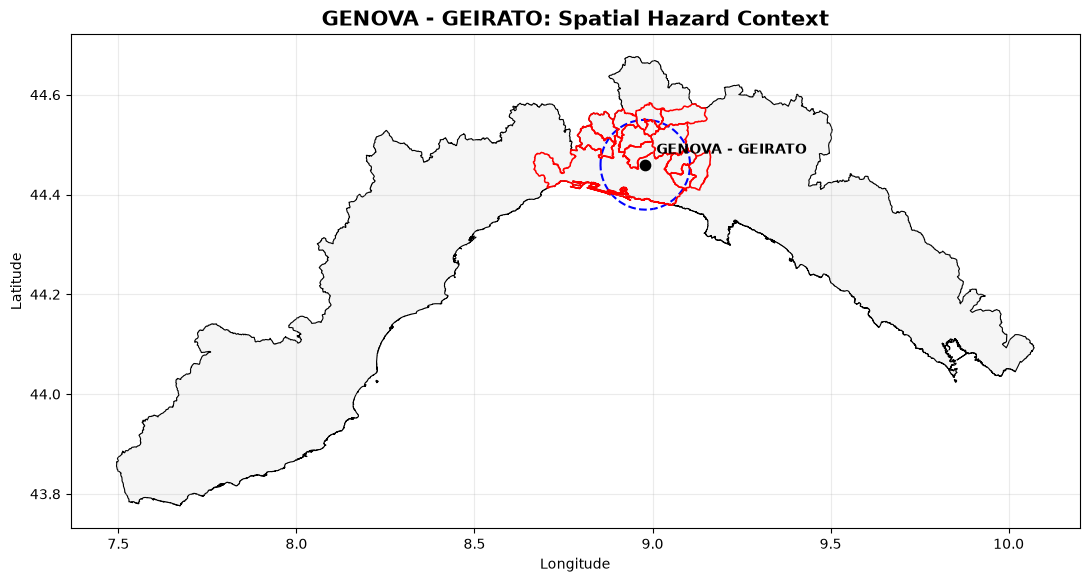

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load Liguria regional boundary
liguria = gpd.read_file("../data/raw/Regione.shp").to_crs("EPSG:4326")

# Convert 10 km buffer to WGS84 for plotting
buffer_wgs84 = station_buffer_10km.to_crs("EPSG:4326")

# Convert selected municipalities to WGS84
municipalities_map = municipalities_near_station_final.to_crs("EPSG:4326")

# Convert station to WGS84
station_map = station_gdf.to_crs("EPSG:4326")

# Create map
fig, ax = plt.subplots(figsize=(11, 8))

# Liguria
liguria.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="black",
    linewidth=0.8
)

# 10 km spatial context
buffer_wgs84.plot(
    ax=ax,
    facecolor="none",
    edgecolor="blue",
    linewidth=1.5,
    linestyle="--"
)

# Municipalities
municipalities_map.plot(
    ax=ax,
    facecolor="none",
    edgecolor="red",
    linewidth=1.1
)

# Station
station_map.plot(
    ax=ax,
    color="black",
    markersize=55,
    zorder=5
)

# Station label
for x, y, label in zip(
    station_map.geometry.x,
    station_map.geometry.y,
    station_map["station"]
):
    ax.annotate(
        label,
        xy=(x, y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    "GENOVA - GEIRATO: Spatial Hazard Context",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [12]:
# Save the spatial hazard context map

from pathlib import Path
import matplotlib.pyplot as plt

output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

output_path = output_dir / "spatial_hazard_context.png"

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

print(f"Map saved to: {output_path}")

Map saved to: ..\outputs\spatial_hazard_context.png


In [13]:
import pandas as pd

comparison = pd.read_csv(
    "../data/processed/precipitation_comparison.csv"
)

comparison["time"] = pd.to_datetime(comparison["time"])

time_diff = comparison["time"].sort_values().diff()

print("Time interval counts:")
print(time_diff.value_counts().head(10))

print("\nNumber of gaps larger than 1 hour:")
print((time_diff > pd.Timedelta(hours=1)).sum())

Time interval counts:
time
0 days 01:00:00    98
0 days 02:00:00     5
0 days 04:00:00     2
0 days 03:00:00     1
Name: count, dtype: int64

Number of gaps larger than 1 hour:
8


In [14]:
# Identify gaps larger than 1 hour

gaps = comparison[
    comparison["time"].sort_values().diff() > pd.Timedelta(hours=1)
].copy()

gaps["previous_time"] = comparison["time"].sort_values().shift(1).loc[gaps.index]
gaps["gap_duration"] = gaps["time"] - gaps["previous_time"]

print(
    gaps[
        ["previous_time", "time", "gap_duration"]
    ].to_string(index=False)
)

      previous_time                time    gap_duration
2014-10-09 08:00:00 2014-10-09 10:00:00 0 days 02:00:00
2014-10-10 20:00:00 2014-10-10 22:00:00 0 days 02:00:00
2014-10-11 10:00:00 2014-10-11 14:00:00 0 days 04:00:00
2014-10-11 16:00:00 2014-10-11 18:00:00 0 days 02:00:00
2014-10-12 12:00:00 2014-10-12 14:00:00 0 days 02:00:00
2014-10-12 14:00:00 2014-10-12 18:00:00 0 days 04:00:00
2014-10-12 18:00:00 2014-10-12 21:00:00 0 days 03:00:00
2014-10-12 21:00:00 2014-10-12 23:00:00 0 days 02:00:00


In [15]:
# Check hourly data completeness during the 9–10 October event

event_data = comparison[
    (comparison["time"] >= "2014-10-09 00:00:00") &
    (comparison["time"] <= "2014-10-10 23:59:59")
].copy()

event_data = event_data.sort_values("time")

expected_hours = pd.date_range(
    start=event_data["time"].min(),
    end=event_data["time"].max(),
    freq="h"
)

missing_hours = expected_hours.difference(event_data["time"])

print("Expected hourly records:", len(expected_hours))
print("Observed records:", len(event_data))
print("Missing hourly records:", len(missing_hours))

print("\nMissing timestamps:")
print(missing_hours)

Expected hourly records: 48
Observed records: 46
Missing hourly records: 2

Missing timestamps:
DatetimeIndex(['2014-10-09 09:00:00', '2014-10-10 21:00:00'], dtype='datetime64[us]', freq=None)


In [16]:
# Time-based rainfall accumulation with missing-hour awareness

event_series = (
    event_data
    .set_index("time")["arpal_precipitation_mm"]
    .sort_index()
)

# Create a complete hourly time index
event_series = event_series.asfreq("h")

# Time-based rolling accumulations
accumulation = pd.DataFrame({
    "precipitation_3h_mm": event_series.rolling("3h", min_periods=3).sum(),
    "precipitation_6h_mm": event_series.rolling("6h", min_periods=6).sum(),
    "precipitation_12h_mm": event_series.rolling("12h", min_periods=12).sum(),
    "precipitation_24h_mm": event_series.rolling("24h", min_periods=24).sum()
})

print("Maximum rainfall accumulations during 9–10 October 2014:")
print(accumulation.max())

print("\nTimes of maximum accumulations:")
print(accumulation.idxmax())

Maximum rainfall accumulations during 9–10 October 2014:
precipitation_3h_mm     215.0
precipitation_6h_mm     256.6
precipitation_12h_mm    265.8
precipitation_24h_mm    438.4
dtype: float64

Times of maximum accumulations:
precipitation_3h_mm    2014-10-09 21:00:00
precipitation_6h_mm    2014-10-09 21:00:00
precipitation_12h_mm   2014-10-10 00:00:00
precipitation_24h_mm   2014-10-10 13:00:00
dtype: datetime64[us]


## Rainfall Accumulation Analysis

Time-based rolling accumulation was used to evaluate the temporal concentration of rainfall during the 9–10 October 2014 event.

The maximum accumulations identified in the cleaned ARPA station dataset were:

| Accumulation Period | Maximum Precipitation |
|---|---:|
| 3-hour | 215.0 mm |
| 6-hour | 256.6 mm |
| 12-hour | 265.8 mm |
| 24-hour | 438.4 mm |

The maximum 3-hour accumulation occurred on 9 October at 21:00, reaching 215.0 mm. The 6-hour maximum reached 256.6 mm, while the maximum 12-hour accumulation reached 265.8 mm.

The 24-hour accumulation reached 438.4 mm, demonstrating that the event involved substantial rainfall accumulation over both short and longer temporal scales.

Because two hourly observations were missing during the event period, time-based rolling windows were used and windows containing insufficient valid observations were excluded. This avoids treating missing observations as zero rainfall and provides a more conservative representation of rainfall accumulation.

These results indicate strong temporal concentration of rainfall and provide an important indicator of the potential severity of the event for flash-flood and urban flood hazard assessment.

v## Hazard Interpretation

The 9–10 October 2014 event shows characteristics of a high-intensity rainfall episode with strong potential relevance to flash-flood and urban flood hazards in the Genoa area.

The cleaned ARPA station dataset recorded a maximum hourly precipitation of **135.0 mm**. The event also produced substantial rainfall accumulation across multiple temporal scales, reaching **215.0 mm over 3 hours**, **256.6 mm over 6 hours**, **265.8 mm over 12 hours**, and **438.4 mm over 24 hours**.

The spatial analysis identified **13 municipalities** intersecting a 10 km spatial context around the GENOVA - GEIRATO station. These municipalities represent the administrative areas geographically associated with the station-based hazard context.

The comparison with Open-Meteo also revealed substantial differences during the most intense rainfall periods. The maximum absolute difference reached **133.7 mm**, with ARPA recording 135.0 mm while Open-Meteo estimated 1.3 mm for the corresponding hourly record in the comparison dataset.

Taken together, the results highlight three important characteristics of the event:

1. **High rainfall intensity** over short time periods.
2. **Substantial rainfall accumulation** across multiple temporal scales.
3. **Strong differences between ground observations and gridded precipitation estimates** during localized extremes.

These findings demonstrate why high-resolution ground observations are important for localized flood-hazard assessment, particularly in urban and mountainous environments such as the Genoa area.

The analysis should be interpreted as a **station-based hazard assessment**, rather than a complete spatial rainfall or flood-risk model for Liguria. The use of a single rainfall station limits the spatial representativeness of the analysis, while missing hourly observations and differences between observational and gridded datasets introduce additional uncertainty.